# H-FGAT rewrite notebook (single-file, Run All)

Notebook này được viết lại để chạy **từ trên xuống dưới một lần** và sinh ra `model.pt`.

Mục tiêu:
- giữ pipeline kiểu author: **user -> outfit -> item**
- đọc được `train_uo.txt` dạng `u1 o1 o2 o3`
- **subsample ~30k user**
- chỉ giữ **outfit/item liên quan**
- chỉ embedding **ảnh thuộc tập subsample**
- train nhẹ hơn cho máy **16GB RAM**
- cuối cùng lưu **`model.pt`** đầy đủ để demo app

## 0) Cần chuẩn bị dữ liệu

Đặt dataset theo dạng:

```text
Dataset/
├── item_data.txt          # columns: item_id, category, image_url, title
├── outfit_data.txt        # columns: outfit_id, items   (items dạng i1;i2;i3)
├── user_data.txt          # columns: user_id, outfits   (outfits dạng o1;o2;o3)
├── train_uo.txt           # optional nhưng khuyến nghị, format: u1 o1 o2 o3
└── fashion_item_images/
    ├── 123.png
    ├── 456.jpg
    └── ...
```

Nếu có `train_uo.txt` thì notebook ưu tiên dùng file này.  
Nếu không có, notebook sẽ tự suy ra user-outfit từ `user_data.txt`.

In [1]:
# =========================
# 1) CONFIG - All hyperparameters for high-memory / Apple Silicon (36GB RAM)
# =========================
from pathlib import Path
import torch

# =========================
# DEVICE SETUP - with MPS support for Apple Silicon
# =========================
# Detect device: MPS (Mac GPU) > CUDA (Nvidia) > CPU
if torch.backends.mps.is_available():
    DEVICE = "mps"  # Metal Performance Shaders for Mac M5/M4/M3/M2/M1
    print("✅ Using MPS (Metal Performance Shaders) for Apple Silicon")
elif torch.cuda.is_available():
    DEVICE = "cuda"  # NVIDIA GPU (e.g., Google Colab)
    print("✅ Using CUDA (NVIDIA GPU)")
else:
    DEVICE = "cpu"  # Fallback to CPU
    print("⚠️ Using CPU (slower, consider using GPU)")

# =========================
# DATA PATHS
# =========================
DATA_ROOT = Path("Dataset")
IMAGE_DIR = DATA_ROOT / "fashion_item_images"
WORK_DIR = Path("output_hfgat_notebook")
WORK_DIR.mkdir(parents=True, exist_ok=True)

# nếu có train_uo.txt thì dùng trực tiếp
TRAIN_UO_PATH = DATA_ROOT / "train_uo.txt"

# =========================
# SUBSAMPLE CONFIG
# =========================
RANDOM_SEED = 42
MIN_USER_INTERACTIONS = 4

# =========================
# FEATURE EXTRACTION
# =========================
FORCE_REBUILD_FEATURES = True
# IMAGE: ResNet152 for 36GB RAM (was ResNet50 for 16GB RAM)
IMAGE_BACKBONE = "resnet152"  # 36GB RAM (resnet152 - deeper, 50M params), 16GB RAM (resnet50 - standard, 25M params)
TEXT_MODEL_NAME = "bert-base-chinese"  # Alternative: "bert-large-chinese" (1024-dim, for 36GB+ RAM)
# Batch sizes: 36GB RAM can handle larger batches
IMAGE_BATCH_SIZE = 64  # 36GB RAM (64), 16GB RAM (32) - process more images at once
TEXT_BATCH_SIZE = 128  # 36GB RAM (128), 16GB RAM (64) - process more text at once
MAX_TEXT_LENGTH = 32
USE_PRETRAINED_BACKBONES = True 

# =========================
# MODEL CONFIG - 36GB RAM OPTIMIZED
# =========================
# Embedding dimensions: doubled for 36GB RAM to capture richer representations
EMBED_DIM = 64  # 36GB RAM (256), 16GB RAM (128) - higher dimensional embeddings
HIDDEN_DIM = 64  # 36GB RAM (256), 16GB RAM (128) - larger hidden layer
DROPOUT = 0.3

# =========================
# TRAINING CONFIG - 36GB RAM OPTIMIZED
# =========================
LR = 0.001
WEIGHT_DECAY = 1e-3
EPOCHS = 40  # 36GB RAM (80 epochs for better convergence), 16GB RAM (30 epochs)
NEG_PER_POS = 5
BATCH_SIZE = 1024  # 36GB RAM (1024), 16GB RAM (512) - larger training batch size
LAMBDA_COMP = 0.1
VAL_RATIO = 0.1
PATIENCE = 10

# =========================
# COMPATIBILITY TASK
# =========================
MAX_OUTFIT_ITEMS_FOR_COMP = 10

# =========================
# CACHE
# =========================
CACHE_DIR = WORK_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

✅ Using MPS (Metal Performance Shaders) for Apple Silicon


In [2]:
import torch
print(torch.__version__)

2.12.0


In [3]:
# =========================
# 2) IMPORTS + SEED
# =========================
import os
import json
import math
import random
import warnings
from collections import defaultdict
from dataclasses import asdict
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(RANDOM_SEED)

# Create device object from DEVICE string
device = torch.device(DEVICE)
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ Using device: {device}")
print(f"📁 data_root: {DATA_ROOT.resolve()}")
print(f"📁 work_dir:  {WORK_DIR.resolve()}")
print(f"🔧 Config: ResNet{152 if IMAGE_BACKBONE == 'resnet152' else 50} + {TEXT_MODEL_NAME}, EMBED_DIM={EMBED_DIM}, EPOCHS={EPOCHS}")

✅ PyTorch version: 2.12.0
✅ Using device: mps
📁 data_root: /Users/quoctran/Documents/999999_HCMUS_Master_Exercises/HocPhan2/2_Research_Methods/hcmus-master-is-research-methods/hfgat_rewrite_validate/Dataset
📁 work_dir:  /Users/quoctran/Documents/999999_HCMUS_Master_Exercises/HocPhan2/2_Research_Methods/hcmus-master-is-research-methods/hfgat_rewrite_validate/output_hfgat_notebook
🔧 Config: ResNet152 + bert-base-chinese, EMBED_DIM=64, EPOCHS=40


## download image 


In [4]:

#****************Source gốc tải ảnh bị quá chậm --> custom phần download

import os
import requests
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed
from threading import local

item_data_path = DATA_ROOT / "item_data.txt"

item_data = pd.read_csv(
    item_data_path, header=None,
    names=['item_id', 'category', 'image_url', 'title']
)

IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# Resume
existing_files = set(
    f.stem for f in IMAGE_DIR.glob("*.png")
)

item_data_sample = item_data[
    ~item_data["item_id"].astype(str).isin(existing_files)
]

total_images = len(item_data_sample)
print(f"🟢 Đã có {len(existing_files)} ảnh | 🟡 Còn {total_images} ảnh cần tải")

headers = {"User-Agent": "Mozilla/5.0"}

_thread_local = local()

def get_session():
    if not hasattr(_thread_local, "session"):
        s = requests.Session()
        s.headers.update(headers)
        _thread_local.session = s
    return _thread_local.session


def download_image(image_url, image_id, retries=2):
    image_path = IMAGE_DIR / f"{image_id}.png"

    if image_path.exists():
        return image_id, image_path

    session = get_session()

    for _ in range(retries):
        try:
            r = session.get(image_url, stream=True, timeout=5)
            if r.status_code == 200:
                with image_path.open("wb") as f:
                    for chunk in r.iter_content(1024):
                        if chunk:
                            f.write(chunk)
                return image_id, image_path
        except requests.exceptions.RequestException:
            continue

    return image_id, None


max_threads = 15
image_paths = {}

completed = 0

with ThreadPoolExecutor(max_workers=max_threads) as ex:
    futures = [
        ex.submit(download_image, row.image_url, row.item_id)
        for row in item_data_sample.itertuples(index=False)
    ]

    for future in as_completed(futures):
        completed += 1
        item_id, path = future.result()

        if path:
            image_paths[item_id] = path
            status = "✅"
        else:
            status = "❌"

        print(f"{status} {completed}/{total_images} | item_id: {item_id}")

print("🎉 Download hoàn tất!")


🟢 Đã có 19167 ảnh | 🟡 Còn 8 ảnh cần tải
❌ 1/8 | item_id: 18133
❌ 2/8 | item_id: 16246
❌ 3/8 | item_id: 9323
❌ 4/8 | item_id: 18749
❌ 5/8 | item_id: 11601
❌ 6/8 | item_id: 12552
❌ 7/8 | item_id: 14835
❌ 8/8 | item_id: 7362
🎉 Download hoàn tất!


In [5]:
# =========================
# 3) HELPERS
# =========================
def read_item_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, header=None, names=["item_id", "category", "image_url", "title"])
    df["item_id"] = df["item_id"].astype(str)
    df["category"] = df["category"].astype(str)
    df["title"] = df["title"].fillna("").astype(str)
    df["image_url"] = df["image_url"].fillna("").astype(str)
    return df

def read_outfit_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, header=None, names=["outfit_id", "items"])
    df["outfit_id"] = df["outfit_id"].astype(str)
    df["items"] = df["items"].fillna("").astype(str)
    return df

def read_user_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, header=None, names=["user_id", "outfits"])
    df["user_id"] = df["user_id"].astype(str)
    df["outfits"] = df["outfits"].fillna("").astype(str)
    return df

def parse_semicolon_list(text: str) -> List[str]:
    text = str(text).strip()
    if not text:
        return []
    return [x.strip() for x in text.split(";") if x.strip()]

def load_train_uo(path: Path) -> pd.DataFrame:
    edges = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            user = str(parts[0])
            outfits = [str(x) for x in parts[1:] if str(x).strip()]
            for o in outfits:
                edges.append((user, o))
    df = pd.DataFrame(edges, columns=["user_id", "outfit_id"])
    return df

def derive_train_uo_from_user_data(user_df: pd.DataFrame) -> pd.DataFrame:
    edges = []
    for row in user_df.itertuples(index=False):
        outfits = parse_semicolon_list(row.outfits)
        for o in outfits:
            edges.append((str(row.user_id), str(o)))
    return pd.DataFrame(edges, columns=["user_id", "outfit_id"])

def available_image_path(IMAGE_DIR: Path, item_id: str):
    for ext in [".png", ".jpg", ".jpeg", ".webp"]:
        p = IMAGE_DIR / f"{item_id}{ext}"
        if p.exists():
            return p
    return None

def save_json(obj, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

In [6]:
# =========================
# 4) LOAD RAW DATA
# =========================
item_df = read_item_data(DATA_ROOT / "item_data.txt")
outfit_df = read_outfit_data(DATA_ROOT / "outfit_data.txt")
user_df = read_user_data(DATA_ROOT / "user_data.txt")

if TRAIN_UO_PATH.exists():
    train_uo_full = load_train_uo(TRAIN_UO_PATH)
    train_uo_source = "train_uo.txt"
else:
    train_uo_full = derive_train_uo_from_user_data(user_df)
    train_uo_source = "derived from user_data.txt"

print("train_uo source :", train_uo_source)
print("raw items       :", len(item_df))
print("raw outfits     :", len(outfit_df))
print("raw users       :", user_df['user_id'].nunique())
print("raw user-outfit :", len(train_uo_full))

display(item_df.head())
display(outfit_df.head())
display(train_uo_full.head())

train_uo source : derived from user_data.txt
raw items       : 19175
raw outfits     : 9373
raw users       : 277469
raw user-outfit : 679028


,item_id,category,image_url,title
0,0,3,http://gw.alicdn.com/imgextra/i3/18/O1CN01b5qP...,yeah jewelry官方店 原创设计首饰小人国耳钉925银镀金女礼物饰品
1,1,10,http://gw.alicdn.com/imgextra/i4/67/O1CN010921...,20199秋冬季新款女装黑色修身长裙气质打底裙中长款毛呢连衣裙
2,2,43,http://gw.alicdn.com/imgextra/i3/77/O1CN01I1Kw...,芍药居少女原创 万能打底裤女薄款经典高腰少女黑直筒紧身裤19春
3,3,16,http://gw.alicdn.com/imgextra/i4/190/O1CN01tu5...,阿俪克斯高腰阔腿裤女春季2019新款刺绣街头条纹开叉运动裤子
4,4,46,http://gw.alicdn.com/imgextra/i4/13/O1CN01kHo0...,Sogo★个性卡通刺绣水洗做旧牛仔弯檐棒球帽男女情侣街头鸭舌帽潮


,outfit_id,items
0,0,15843;245;5923
1,1,891;5964;4403
2,2,2243;5098;4258;6052;435
3,3,2650;93;8815;3008
4,4,16689;13828;12083;12846;364


,user_id,outfit_id
0,844126,1277
1,844126,3165
2,844130,2805
3,844146,4965
4,844162,8424


In [7]:
# =========================
# 5) SUBSAMPLE PIPELINE
# Keep users with >= MIN_USER_INTERACTIONS interactions (defined in config)
# Workflow: user -> outfit -> item -> image
# =========================
# Note: MIN_USER_INTERACTIONS is now defined in CONFIG section at top

# 1) Dedup edges first
train_uo_base = train_uo_full.drop_duplicates(subset=["user_id", "outfit_id"]).copy().reset_index(drop=True)

# 2) Keep only sufficiently active users
user_inter_counts = train_uo_base["user_id"].value_counts()
active_users = set(user_inter_counts[user_inter_counts >= MIN_USER_INTERACTIONS].index.tolist())

train_uo_sub = train_uo_base[train_uo_base["user_id"].isin(active_users)].copy().reset_index(drop=True)

# 3) Get outfits that appear in filtered edges
valid_outfit_ids = set(train_uo_sub["outfit_id"].unique().tolist())
outfit_sub = outfit_df[outfit_df["outfit_id"].isin(valid_outfit_ids)].copy().reset_index(drop=True)

# 4) Get items from outfits
valid_item_ids = set()
for items_str in outfit_sub["items"].tolist():
    valid_item_ids.update(parse_semicolon_list(items_str))

item_sub = item_df[item_df["item_id"].isin(valid_item_ids)].copy().reset_index(drop=True)

# 5) Keep only items with actual images
item_sub["image_path"] = item_sub["item_id"].apply(lambda x: available_image_path(IMAGE_DIR, x))
item_sub["has_image"] = item_sub["image_path"].notnull()
item_sub = item_sub[item_sub["has_image"]].copy().reset_index(drop=True)

final_item_ids = set(item_sub["item_id"].tolist())

# 6) Filter items in outfits based on final item list
def filter_outfit_items(items_str: str) -> str:
    items = [x for x in parse_semicolon_list(items_str) if x in final_item_ids]
    return ";".join(items)

outfit_sub["items"] = outfit_sub["items"].apply(filter_outfit_items)
outfit_sub = outfit_sub[outfit_sub["items"].str.len() > 0].copy().reset_index(drop=True)

# 7) Filter edges based on final outfits
final_outfit_ids = set(outfit_sub["outfit_id"].tolist())
train_uo_sub = train_uo_sub[train_uo_sub["outfit_id"].isin(final_outfit_ids)].copy().reset_index(drop=True)

# 8) Filter users after outfit removal
final_user_ids = set(train_uo_sub["user_id"].tolist())
user_sub = user_df[user_df["user_id"].isin(final_user_ids)].copy().reset_index(drop=True)

# 9) Filter items based on final outfits
used_item_ids = set()
for items_str in outfit_sub["items"].tolist():
    used_item_ids.update(parse_semicolon_list(items_str))

item_sub = item_sub[item_sub["item_id"].isin(used_item_ids)].copy().reset_index(drop=True)

# 10) Print statistics
print("🔍 SUBSAMPLE STATISTICS:")
print(f"  min interactions   : {MIN_USER_INTERACTIONS}")
print(f"  filtered users     : {train_uo_sub['user_id'].nunique()}")
print(f"  filtered outfits   : {len(outfit_sub)}")
print(f"  filtered items     : {len(item_sub)}")
print(f"  items with images  : {int(item_sub['has_image'].sum())}")
print(f"  user-outfit edges  : {len(train_uo_sub)}")
print(f"  avg interactions   : {len(train_uo_sub) / max(1, train_uo_sub['user_id'].nunique()):.2f}")

🔍 SUBSAMPLE STATISTICS:
  min interactions   : 4
  filtered users     : 25263
  filtered outfits   : 6622
  filtered items     : 14419
  items with images  : 14419
  user-outfit edges  : 127536
  avg interactions   : 5.05


In [8]:
# # =========================
# # 5) SUBSAMPLE PIPELINE
# # user -> outfit -> item -> image
# # =========================
# rng = np.random.default_rng(RANDOM_SEED)

# all_users = train_uo_full["user_id"].drop_duplicates().tolist()
# sample_n = min(TARGET_NUM_USERS, len(all_users))
# sampled_users = rng.choice(np.array(all_users, dtype=object), size=sample_n, replace=False).tolist()

# train_uo_sub = train_uo_full[train_uo_full["user_id"].isin(sampled_users)].copy()
# train_uo_sub = train_uo_sub.drop_duplicates().reset_index(drop=True)

# valid_outfit_ids = set(train_uo_sub["outfit_id"].unique().tolist())
# outfit_sub = outfit_df[outfit_df["outfit_id"].isin(valid_outfit_ids)].copy()

# valid_item_ids = set()
# for items_str in outfit_sub["items"].tolist():
#     valid_item_ids.update(parse_semicolon_list(items_str))

# item_sub = item_df[item_df["item_id"].isin(valid_item_ids)].copy()

# # chỉ giữ outfit còn item hợp lệ
# item_sub_ids = set(item_sub["item_id"].tolist())

# def filter_outfit_items(items_str: str) -> str:
#     items = [x for x in parse_semicolon_list(items_str) if x in item_sub_ids]
#     return ";".join(items)

# outfit_sub["items"] = outfit_sub["items"].apply(filter_outfit_items)
# outfit_sub = outfit_sub[outfit_sub["items"].str.len() > 0].copy()
# valid_outfit_ids = set(outfit_sub["outfit_id"].tolist())

# train_uo_sub = train_uo_sub[train_uo_sub["outfit_id"].isin(valid_outfit_ids)].copy().reset_index(drop=True)

# # lọc lại item theo outfit cuối
# final_item_ids = set()
# for items_str in outfit_sub["items"].tolist():
#     final_item_ids.update(parse_semicolon_list(items_str))
# item_sub = item_sub[item_sub["item_id"].isin(final_item_ids)].copy().reset_index(drop=True)

# # user table chỉ để tham khảo/debug
# user_sub = user_df[user_df["user_id"].isin(set(train_uo_sub["user_id"]))].copy()

# # kiểm tra ảnh có thật
# item_sub["image_path"] = item_sub["item_id"].apply(lambda x: available_image_path(IMAGE_DIR, x))
# item_sub["has_image"] = item_sub["image_path"].notnull()

# print("sampled users      :", train_uo_sub['user_id'].nunique())
# print("sampled outfits    :", len(outfit_sub))
# print("sampled items      :", len(item_sub))
# print("items with images  :", int(item_sub['has_image'].sum()))
# print("user-outfit edges  :", len(train_uo_sub))


In [12]:
# =========================
# 6) SAVE SUBSAMPLED ARTIFACTS
# =========================
SUB_DIR = WORK_DIR / "subsample"
SUB_DIR.mkdir(parents=True, exist_ok=True)

item_sub[["item_id", "category", "image_url", "title"]].to_csv(SUB_DIR / "item_sub.csv", index=False)
outfit_sub[["outfit_id", "items"]].to_csv(SUB_DIR / "outfit_sub.csv", index=False)
user_sub[["user_id", "outfits"]].to_csv(SUB_DIR / "user_sub.csv", index=False)
train_uo_sub[["user_id", "outfit_id"]].to_csv(SUB_DIR / "train_uo_sub.csv", index=False)

save_json(
    {
        "sampled_users": int(train_uo_sub["user_id"].nunique()),
        "sampled_outfits": int(len(outfit_sub)),
        "sampled_items": int(len(item_sub)),
        "items_with_images": int(item_sub["has_image"].sum()),
        "train_uo_source": train_uo_source,
    },
    SUB_DIR / "subsample_stats.json"
)

print("saved subsample files to:", SUB_DIR.resolve())

saved subsample files to: /Users/quoctran/Documents/999999_HCMUS_Master_Exercises/HocPhan2/2_Research_Methods/hcmus-master-is-research-methods/hfgat_rewrite_validate/output_hfgat_notebook/subsample


### Xuất file train_uo cho việc App.py run chức năng kia

## 7) Feature extraction

Cell này chỉ embedding **item thuộc subsample**.  
Ảnh dùng đúng file trong `fashion_item_images/` theo tên `item_id`.

In [13]:
# =========================
# 7A) LOAD FEATURE BACKBONES
# =========================
from torchvision import models, transforms
from transformers import AutoTokenizer, AutoModel

if IMAGE_BACKBONE == "resnet152":
    if USE_PRETRAINED_BACKBONES:
        weights = models.ResNet152_Weights.DEFAULT
        image_model = models.resnet152(weights=weights)
        image_tf = weights.transforms()
    else:
        image_model = models.resnet152(weights=None)
        image_tf = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    image_feat_dim = 2048
elif IMAGE_BACKBONE == "resnet50":
    if USE_PRETRAINED_BACKBONES:
        weights = models.ResNet50_Weights.DEFAULT
        image_model = models.resnet50(weights=weights)
        image_tf = weights.transforms()
    else:
        image_model = models.resnet50(weights=None)
        image_tf = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    image_feat_dim = 2048
else:
    raise ValueError(f"Unsupported IMAGE_BACKBONE: {IMAGE_BACKBONE}. Expected 'resnet152' or 'resnet50'.")

image_model = nn.Sequential(*list(image_model.children())[:-1]).to(device)
image_model.eval()

tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)
text_model = AutoModel.from_pretrained(TEXT_MODEL_NAME).to(device)
text_model.eval()
text_feat_dim = int(text_model.config.hidden_size)

all_categories = sorted(item_sub["category"].astype(str).unique().tolist())
cat2idx = {c: i for i, c in enumerate(all_categories)}
cat_feat_dim = len(cat2idx)

print("image_feat_dim =", image_feat_dim)
print("text_feat_dim  =", text_feat_dim)
print("cat_feat_dim   =", cat_feat_dim)

Loading weights: 100%|█| 199/199 [00:00<00:00, 20404.00
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


image_feat_dim = 2048
text_feat_dim  = 768
cat_feat_dim   = 59


In [14]:
# =========================
# 7B) EXTRACT / CACHE ITEM FEATURES
# =========================
feature_cache_path = CACHE_DIR / "item_features.pt"

def batch_text_features(texts: List[str]) -> torch.Tensor:
    outputs = []
    for i in range(0, len(texts), TEXT_BATCH_SIZE):
        batch_text = texts[i:i+TEXT_BATCH_SIZE]
        toks = tokenizer(
            batch_text,
            padding=True,
            truncation=True,
            max_length=MAX_TEXT_LENGTH,
            return_tensors="pt"
        )
        toks = {k: v.to(device) for k, v in toks.items()}
        with torch.no_grad():
            out = text_model(**toks).last_hidden_state[:, 0, :]
        outputs.append(out.cpu())
    return torch.cat(outputs, dim=0)

def batch_image_features(image_paths: List[Path]) -> torch.Tensor:
    feats = []
    batch_imgs = []
    for p in image_paths:
        try:
            img = Image.open(p).convert("RGB")
            batch_imgs.append(image_tf(img))
        except Exception:
            batch_imgs.append(torch.zeros(3, 224, 224))
        if len(batch_imgs) == IMAGE_BATCH_SIZE:
            x = torch.stack(batch_imgs).to(device)
            with torch.no_grad():
                f = image_model(x).flatten(1).cpu()
            feats.append(f)
            batch_imgs = []
    if batch_imgs:
        x = torch.stack(batch_imgs).to(device)
        with torch.no_grad():
            f = image_model(x).flatten(1).cpu()
        feats.append(f)
    return torch.cat(feats, dim=0)

if feature_cache_path.exists() and not FORCE_REBUILD_FEATURES:
    cached = torch.load(feature_cache_path, map_location="cpu", weights_only=False)
    item_features_df = cached["meta"].copy()
    image_feat = cached["image_feat"].float()
    text_feat = cached["text_feat"].float()
    cat_feat = cached["cat_feat"].float()
    print("loaded cached item features from", feature_cache_path)
else:
    if feature_cache_path.exists():
        print("FORCE_REBUILD_FEATURES=True, regenerating", feature_cache_path)
    else:
        print("cache not found, extracting item features to", feature_cache_path)

    work_items = item_sub.copy().reset_index(drop=True)

    # text
    text_inputs = (
        work_items["title"].fillna("").astype(str)
        + " [SEP] "
        + work_items["category"].fillna("").astype(str)
    ).tolist()
    text_feat = batch_text_features(text_inputs)

    # image
    image_paths = []
    for row in work_items.itertuples(index=False):
        p = row.image_path
        image_paths.append(Path(p) if p is not None else None)

    safe_paths = [p if p is not None else None for p in image_paths]
    image_feat_list = []
    for i in range(0, len(safe_paths), IMAGE_BATCH_SIZE):
        chunk = safe_paths[i:i+IMAGE_BATCH_SIZE]
        imgs = []
        for p in chunk:
            try:
                if p is None:
                    raise FileNotFoundError("missing image")
                img = Image.open(p).convert("RGB")
                imgs.append(image_tf(img))
            except Exception:
                imgs.append(torch.zeros(3, 224, 224))
        x = torch.stack(imgs).to(device)
        with torch.no_grad():
            f = image_model(x).flatten(1).cpu()
        image_feat_list.append(f)
    image_feat = torch.cat(image_feat_list, dim=0)

    # category one-hot
    cat_indices = [cat2idx[c] for c in work_items["category"].astype(str).tolist()]
    cat_feat = F.one_hot(torch.tensor(cat_indices), num_classes=cat_feat_dim).float()

    item_features_df = work_items[["item_id", "category", "title", "has_image"]].copy()

    torch.save(
        {
            "meta": item_features_df,
            "image_feat": image_feat,
            "text_feat": text_feat,
            "cat_feat": cat_feat,
        },
        feature_cache_path,
    )
    print("saved cached item features to", feature_cache_path)

print("feature tensors:")
print(" image_feat:", tuple(image_feat.shape))
print(" text_feat :", tuple(text_feat.shape))
print(" cat_feat  :", tuple(cat_feat.shape))


cache not found, extracting item features to output_hfgat_notebook/cache/item_features.pt
saved cached item features to output_hfgat_notebook/cache/item_features.pt
feature tensors:
 image_feat: (14419, 2048)
 text_feat : (14419, 768)
 cat_feat  : (14419, 59)


In [15]:
# =========================
# 8) BUILD MAPPINGS + STATIC SPARSE GRAPHS
# =========================
item_ids = item_sub["item_id"].astype(str).tolist()
outfit_ids = outfit_sub["outfit_id"].astype(str).tolist()
user_ids = sorted(train_uo_sub["user_id"].astype(str).unique().tolist())

item2idx = {x: i for i, x in enumerate(item_ids)}
outfit2idx = {x: i for i, x in enumerate(outfit_ids)}
user2idx = {x: i for i, x in enumerate(user_ids)}

# outfit -> items edges
outfit_item_edges = []
for row in outfit_sub.itertuples(index=False):
    oidx = outfit2idx[str(row.outfit_id)]
    for item_id in parse_semicolon_list(row.items):
        if item_id in item2idx:
            outfit_item_edges.append((oidx, item2idx[item_id]))

# user -> outfit edges (full, chỉ để phân tích / export; KHÔNG dùng train trực tiếp)
user_outfit_edges_all = []
for row in train_uo_sub.itertuples(index=False):
    u = str(row.user_id)
    o = str(row.outfit_id)
    if u in user2idx and o in outfit2idx:
        user_outfit_edges_all.append((user2idx[u], outfit2idx[o]))

# item-item graph by same category (lightweight)
# cat_groups = defaultdict(list)
# for row in item_sub.itertuples(index=False):
#     cat_groups[str(row.category)].append(item2idx[str(row.item_id)])

# item_item_edges = set()
# for _, idxs in cat_groups.items():
#     if len(idxs) <= 1:
#         continue
#     # star connection around first item to reduce density
#     root = idxs[0]
#     for j in idxs[1:]:
#         item_item_edges.add((root, j))
#         item_item_edges.add((j, root))

def make_sparse_from_edges(num_src, num_dst, edges, add_self=False, square=False):
    if square:
        rows, cols = zip(*edges) if edges else ([], [])
        rows = list(rows)
        cols = list(cols)
        if add_self:
            for i in range(num_src):
                rows.append(i)
                cols.append(i)
        idx = torch.tensor([rows, cols], dtype=torch.long)
        val = torch.ones(idx.shape[1], dtype=torch.float32)
        A = torch.sparse_coo_tensor(idx, val, (num_src, num_src)).coalesce()
        deg = torch.sparse.sum(A, dim=1).to_dense().clamp_min(1.0)
        norm_val = A.values() / deg[A.indices()[0]]
        A = torch.sparse_coo_tensor(A.indices(), norm_val, A.shape).coalesce()
        return A
    else:
        rows, cols = zip(*edges) if edges else ([], [])
        idx = torch.tensor([list(rows), list(cols)], dtype=torch.long) if edges else torch.empty((2,0), dtype=torch.long)
        val = torch.ones(idx.shape[1], dtype=torch.float32)
        A = torch.sparse_coo_tensor(idx, val, (num_src, num_dst)).coalesce()
        deg = torch.sparse.sum(A, dim=1).to_dense().clamp_min(1.0)
        norm_val = A.values() / deg[A.indices()[0]]
        A = torch.sparse_coo_tensor(A.indices(), norm_val, A.shape).coalesce()
        return A


# =========================
# item-item graph: category + co-occurrence, keep top-10 neighbors
# =========================
from collections import defaultdict, Counter
import math

# 1) category edges
cat_edge_weight = defaultdict(float)
cat_groups = defaultdict(list)
for row in item_sub.itertuples(index=False):
    cat_groups[str(row.category)].append(item2idx[str(row.item_id)])

for _, idxs in cat_groups.items():
    idxs = list(set(idxs))
    if len(idxs) <= 1:
        continue
    w = 1.0 / math.log2(len(idxs) + 1.0)
    for i in range(len(idxs)):
        for j in range(i + 1, len(idxs)):
            a, b = idxs[i], idxs[j]
            cat_edge_weight[(a, b)] += w
            cat_edge_weight[(b, a)] += w

# 2) co-occurrence edges from outfit -> items
pair_count = Counter()
item_freq = Counter()

for row in outfit_sub.itertuples(index=False):
    items = [item2idx[x] for x in parse_semicolon_list(row.items) if x in item2idx]
    items = sorted(set(items))
    for i in items:
        item_freq[i] += 1
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            a, b = items[i], items[j]
            pair_count[(a, b)] += 1
            pair_count[(b, a)] += 1

cooc_edge_weight = {}
for (i, j), c in pair_count.items():
    cooc_edge_weight[(i, j)] = c / math.sqrt(max(item_freq[i], 1) * max(item_freq[j], 1))

# 3) combine weights
combined_edge_weight = defaultdict(float)

for (i, j), w in cat_edge_weight.items():
    combined_edge_weight[(i, j)] += 0.3 * w

for (i, j), w in cooc_edge_weight.items():
    combined_edge_weight[(i, j)] += 0.7 * w

# 4) keep top-10 neighbors per item
neighbors = defaultdict(list)
for (i, j), w in combined_edge_weight.items():
    if i != j:
        neighbors[i].append((j, float(w)))

item_item_edges = set()
for i in range(len(item2idx)):
    top_neighbors = sorted(neighbors[i], key=lambda x: x[1], reverse=True)[:10]
    for j, _ in top_neighbors:
        item_item_edges.add((i, j))
        item_item_edges.add((j, i))   # symmetrize

A_item = make_sparse_from_edges(
    len(item2idx),
    len(item2idx),
    list(item_item_edges),
    add_self=True,
    square=True
)

A_item = make_sparse_from_edges(len(item2idx), len(item2idx), list(item_item_edges), add_self=True, square=True)
A_outfit_item = make_sparse_from_edges(len(outfit2idx), len(item2idx), outfit_item_edges)
A_user_outfit_full = make_sparse_from_edges(len(user2idx), len(outfit2idx), user_outfit_edges_all)

print("num_users             =", len(user2idx))
print("num_outfits           =", len(outfit2idx))
print("num_items             =", len(item2idx))
print("user-outfit edges all =", len(user_outfit_edges_all))
print("outfit-item edges     =", len(outfit_item_edges))
print("item-item edges       =", len(item_item_edges))


num_users             = 25263
num_outfits           = 6622
num_items             = 14419
user-outfit edges all = 127536
outfit-item edges     = 26047
item-item edges       = 236870


In [16]:
# =========================
# 9) USER-AWARE TRAIN / VAL / TEST SPLIT + DATASET
# edge ratio ~ 8:1:1 (KHÔNG ép mọi user đều có val/test)
# =========================
import numpy as np
import pandas as pd
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader

edges_df = pd.DataFrame(
    user_outfit_edges_all,
    columns=["user_idx", "outfit_idx"]
).drop_duplicates().reset_index(drop=True)

print("avg interactions/user:", len(edges_df) / max(1, edges_df["user_idx"].nunique()))


def stratified_user_holdout_ratio(edges_df, val_ratio=0.1, test_ratio=0.1, seed=42, min_train_per_user=1):
 
    rng = np.random.default_rng(seed)

    train_parts = []
    val_parts = []
    test_parts = []

    for user_idx, grp in edges_df.groupby("user_idx", sort=False):
        grp = grp.sample(
            frac=1.0,
            random_state=int(rng.integers(1_000_000_000))
        ).reset_index(drop=True)

        n = len(grp)

        # quá ít interaction -> để train hết
        if n <= min_train_per_user:
            train_parts.append(grp)
            continue

        n_val = int(round(n * val_ratio))
        n_test = int(round(n * test_ratio))

        # nếu val+test quá nhiều thì cắt để train còn >= min_train_per_user
        max_holdout = n - min_train_per_user
        if n_val + n_test > max_holdout:
            overflow = (n_val + n_test) - max_holdout

            reduce_test = min(overflow, n_test)
            n_test -= reduce_test
            overflow -= reduce_test

            reduce_val = min(overflow, n_val)
            n_val -= reduce_val
            overflow -= reduce_val

        n_train = n - n_val - n_test

        # safety
        assert n_train >= min_train_per_user
        assert n_val >= 0
        assert n_test >= 0
        assert n_train + n_val + n_test == n

        if n_test > 0:
            test_parts.append(grp.iloc[:n_test].copy())
        if n_val > 0:
            val_parts.append(grp.iloc[n_test:n_test + n_val].copy())
        train_parts.append(grp.iloc[n_test + n_val:].copy())

    train_df = pd.concat(train_parts, ignore_index=True) if train_parts else pd.DataFrame(columns=edges_df.columns)
    val_df = pd.concat(val_parts, ignore_index=True) if val_parts else pd.DataFrame(columns=edges_df.columns)
    test_df = pd.concat(test_parts, ignore_index=True) if test_parts else pd.DataFrame(columns=edges_df.columns)

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


train_edges_df, val_edges_df, test_edges_df = stratified_user_holdout_ratio(
    edges_df,
    val_ratio=0.1,
    test_ratio=0.1,
    seed=RANDOM_SEED,
    min_train_per_user=1,
)

# -------------------------
# positive sets
# -------------------------
user_pos_all = defaultdict(set)
for row in edges_df.itertuples(index=False):
    user_pos_all[int(row.user_idx)].add(int(row.outfit_idx))

user_pos_train = defaultdict(set)
for row in train_edges_df.itertuples(index=False):
    user_pos_train[int(row.user_idx)].add(int(row.outfit_idx))

user_pos_val = defaultdict(set)
for row in val_edges_df.itertuples(index=False):
    user_pos_val[int(row.user_idx)].add(int(row.outfit_idx))

user_pos_test = defaultdict(set)
for row in test_edges_df.itertuples(index=False):
    user_pos_test[int(row.user_idx)].add(int(row.outfit_idx))

user_pos_train_val = defaultdict(set)
for u, s in user_pos_train.items():
    user_pos_train_val[u].update(s)
for u, s in user_pos_val.items():
    user_pos_train_val[u].update(s)

# graph cho training
A_user_outfit_train = make_sparse_from_edges(
    len(user2idx),
    len(outfit2idx),
    train_edges_df[["user_idx", "outfit_idx"]].to_records(index=False).tolist()
)

# -------------------------
# stats
# -------------------------
split_stats = {
    "all_edges": int(len(edges_df)),
    "train_edges": int(len(train_edges_df)),
    "val_edges": int(len(val_edges_df)),
    "test_edges": int(len(test_edges_df)),

    "train_ratio": float(len(train_edges_df) / max(1, len(edges_df))),
    "val_ratio": float(len(val_edges_df) / max(1, len(edges_df))),
    "test_ratio": float(len(test_edges_df) / max(1, len(edges_df))),

    "train_users": int(train_edges_df["user_idx"].nunique()) if len(train_edges_df) else 0,
    "val_users": int(val_edges_df["user_idx"].nunique()) if len(val_edges_df) else 0,
    "test_users": int(test_edges_df["user_idx"].nunique()) if len(test_edges_df) else 0,

    "users_with_val": int(sum(len(v) > 0 for v in user_pos_val.values())),
    "users_with_test": int(sum(len(v) > 0 for v in user_pos_test.values())),

    "users_in_val_not_in_train": int(
        val_edges_df[~val_edges_df["user_idx"].isin(train_edges_df["user_idx"])]["user_idx"].nunique()
    ) if len(val_edges_df) else 0,

    "users_in_test_not_in_train": int(
        test_edges_df[~test_edges_df["user_idx"].isin(train_edges_df["user_idx"])]["user_idx"].nunique()
    ) if len(test_edges_df) else 0,
}


class BPRDataset(Dataset):
    def __init__(self, edges_df, user_pos_dict_for_negative, num_outfits, seed=42):
        self.edges = edges_df[["user_idx", "outfit_idx"]].to_records(index=False).tolist()
        self.user_pos_dict = user_pos_dict_for_negative
        self.num_outfits = num_outfits
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.edges)

    def __getitem__(self, idx):
        user_idx, pos_outfit = self.edges[idx]
        user_idx = int(user_idx)
        pos_outfit = int(pos_outfit)

        pos_set = self.user_pos_dict[user_idx]
        neg_outfit = int(self.rng.integers(0, self.num_outfits))
        while neg_outfit in pos_set:
            neg_outfit = int(self.rng.integers(0, self.num_outfits))

        return {
            "user_idx": user_idx,
            "pos_outfit_idx": pos_outfit,
            "neg_outfit_idx": neg_outfit,
        }


# train: tránh positive trong train
train_ds = BPRDataset(
    train_edges_df,
    user_pos_train,
    len(outfit2idx),
    seed=RANDOM_SEED,
)

# val/test: tránh positive trong toàn bộ data để không sample nhầm false negative
val_ds = BPRDataset(
    val_edges_df,
    user_pos_all,
    len(outfit2idx),
    seed=RANDOM_SEED + 1,
) if len(val_edges_df) else None

test_ds = BPRDataset(
    test_edges_df,
    user_pos_all,
    len(outfit2idx),
    seed=RANDOM_SEED + 2,
) if len(test_edges_df) else None


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False) if val_ds is not None else None
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False) if test_ds is not None else None


print("split_stats:")
for k, v in split_stats.items():
    print(f"  {k}: {v}")

avg interactions/user: 5.0483315520722005
split_stats:
  all_edges: 127536
  train_edges: 115948
  val_edges: 5794
  test_edges: 5794
  train_ratio: 0.9091393802534187
  val_ratio: 0.04543030987329068
  test_ratio: 0.04543030987329068
  train_users: 25263
  val_users: 5543
  test_users: 5543
  users_with_val: 5543
  users_with_test: 5543
  users_in_val_not_in_train: 0
  users_in_test_not_in_train: 0


In [17]:
# =========================
# 10) COMPATIBILITY TENSORS — hard negative (same category)
# =========================

outfit_item_lists = []
for o in outfit_ids:
    items = parse_semicolon_list(outfit_sub.loc[outfit_sub["outfit_id"] == o, "items"].iloc[0])
    idxs = [item2idx[x] for x in items if x in item2idx]
    outfit_item_lists.append(idxs)

item_pool = list(range(len(item2idx)))

def pad_or_truncate(xs, max_len, pad_val=-1):
    xs = list(xs)[:max_len]
    if len(xs) < max_len:
        xs = xs + [pad_val] * (max_len - len(xs))
    return xs

# build map: item_idx -> category, category -> [item_idx, ...]
idx2item = {v: k for k, v in item2idx.items()}
item_sub["item_id_str"] = item_sub["item_id"].astype(str)
iid_to_cat = dict(zip(item_sub["item_id_str"], item_sub["category"]))

cat_to_idxs = {}
for idx in item_pool:
    iid = str(idx2item[idx])
    cat = iid_to_cat.get(iid, None)
    if cat is not None:
        cat_to_idxs.setdefault(cat, []).append(idx)

def sample_hard_neg(pos_idx, idxs_in_outfit, rng):
    """Lấy candidate cùng category với pos_idx, không thuộc outfit."""
    iid = str(idx2item[pos_idx])
    cat = iid_to_cat.get(iid, None)

    if cat is not None and cat in cat_to_idxs:
        pool = [x for x in cat_to_idxs[cat] if x not in idxs_in_outfit]
    else:
        pool = []

    # fallback: random nếu same-cat pool rỗng hoặc quá nhỏ
    if len(pool) < 2:
        pool = [x for x in item_pool if x not in idxs_in_outfit]

    if len(pool) == 0:
        return None

    return int(rng.choice(pool))

def make_compat_pairs(indices, outfit_item_lists, rng, max_len):
    pos_list, neg_list = [], []
    for i in indices:
        idxs = outfit_item_lists[i]
        if len(idxs) == 0:
            continue
        pos = pad_or_truncate(idxs, max_len)
        neg = list(pos)
        valid = [j for j, x in enumerate(pos) if x >= 0]
        if not valid:
            continue
        rp = int(rng.choice(valid))
        candidate = sample_hard_neg(pos[rp], idxs, rng)
        if candidate is None:
            continue
        neg[rp] = candidate
        pos_list.append(pos)
        neg_list.append(neg)
    return (
        torch.tensor(pos_list, dtype=torch.long),
        torch.tensor(neg_list, dtype=torch.long),
    )

# split theo outfit 80/20
rng_local = np.random.default_rng(RANDOM_SEED)
all_outfit_indices = list(range(len(outfit_item_lists)))
rng_local.shuffle(all_outfit_indices)

n_train_o = int(len(all_outfit_indices) * 0.8)
train_outfit_indices = all_outfit_indices[:n_train_o]
val_outfit_indices   = all_outfit_indices[n_train_o:]

compat_pos_train_t, compat_neg_train_t = make_compat_pairs(
    train_outfit_indices, outfit_item_lists, rng_local, MAX_OUTFIT_ITEMS_FOR_COMP)
compat_pos_val_t, compat_neg_val_t = make_compat_pairs(
    val_outfit_indices, outfit_item_lists, rng_local, MAX_OUTFIT_ITEMS_FOR_COMP)

compat_pos_train_t = compat_pos_train_t.to(device)
compat_neg_train_t = compat_neg_train_t.to(device)
compat_pos_val_t   = compat_pos_val_t.to(device)
compat_neg_val_t   = compat_neg_val_t.to(device)

print(f"compat train : {len(compat_pos_train_t)}")
print(f"compat val   : {len(compat_pos_val_t)}")

compat train : 5297
compat val   : 1325


In [18]:
# =========================
# 11) MODEL
# lightweight H-FGAT-style hierarchical encoder
# no torch_scatter / no torch_geometric required
# =========================
class MLPBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim),
        )
    def forward(self, x):
        return self.net(x)
class OutfitSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # x: (B, max_items, embed_dim)
        # mask: (B, max_items) — True = padding (ignore)
        attn_out, _ = self.attn(x, x, x, key_padding_mask=mask)
        x = self.norm(x + self.dropout(attn_out))
        return x

class HFGATLite(nn.Module):
    def __init__(self, image_dim, text_dim, cat_dim, num_users, num_outfits, num_items,
                 embed_dim=128, dropout=0.1):
        super().__init__()
        self.outfit_attn = OutfitSelfAttention(embed_dim, num_heads=4, dropout=dropout)

        self.embed_dim = embed_dim
        self.num_users = num_users
        self.num_outfits = num_outfits
        self.num_items = num_items

        self.image_proj = nn.Linear(image_dim, embed_dim)
        self.text_proj = nn.Linear(text_dim, embed_dim)
        self.cat_proj = nn.Linear(cat_dim, embed_dim)

        self.item_fuse = MLPBlock(embed_dim * 3, embed_dim, dropout=dropout)
        self.item_update = MLPBlock(embed_dim, embed_dim, dropout=dropout)
        self.outfit_update = MLPBlock(embed_dim, embed_dim, dropout=dropout)
        self.user_update = MLPBlock(embed_dim, embed_dim, dropout=dropout)

        self.user_base = nn.Embedding(num_users, embed_dim)
        self.outfit_base = nn.Embedding(num_outfits, embed_dim)

        self.dropout = nn.Dropout(dropout)
        self.compat_mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, 1)
        )
        self.scorer = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, 1)
        )

    def encode_items(self, image_feat, text_feat, cat_feat, A_item):
        x_img = self.image_proj(image_feat)
        x_txt = self.text_proj(text_feat)
        x_cat = self.cat_proj(cat_feat)
        x = torch.cat([x_img, x_txt, x_cat], dim=-1)
        x = self.item_fuse(x)
        x_prop = torch.sparse.mm(A_item, x)
        x = x + self.dropout(self.item_update(x_prop))
        return F.normalize(x, p=2, dim=-1)  # Fix 9: normalize item embs (author normalizes all layers)

    def encode_outfits(self, item_emb, A_outfit_item):
        outfit_from_items = torch.sparse.mm(A_outfit_item, item_emb)
        base_norm = F.normalize(self.outfit_base.weight, p=2, dim=-1)
        prop_norm = F.normalize(outfit_from_items, p=2, dim=-1)
        out = base_norm + self.dropout(self.outfit_update(prop_norm))
        return F.normalize(out, p=2, dim=-1)

    def encode_users(self, outfit_emb, A_user_outfit):
        user_from_outfits = torch.sparse.mm(A_user_outfit, outfit_emb)
        base_norm = F.normalize(self.user_base.weight, p=2, dim=-1)
        prop_norm = F.normalize(user_from_outfits, p=2, dim=-1)
        usr = base_norm + self.dropout(self.user_update(prop_norm))
        return F.normalize(usr, p=2, dim=-1)

    def forward(self, image_feat, text_feat, cat_feat, A_item, A_outfit_item, A_user_outfit):
        item_emb = self.encode_items(image_feat, text_feat, cat_feat, A_item)
        outfit_emb = self.encode_outfits(item_emb, A_outfit_item)
        user_emb = self.encode_users(outfit_emb, A_user_outfit)
        return user_emb, outfit_emb, item_emb

    def score_user_outfit(self, user_emb, outfit_emb, user_idx, outfit_idx):
        u = user_emb[user_idx]
        o = outfit_emb[outfit_idx]
        x = torch.cat([u, o], dim=-1)
        return self.scorer(x).squeeze(-1)

    def score_compatibility(self, item_emb, outfit_item_idx_batch):
        # outfit_item_idx_batch: (B, max_items), -1 = padding
        mask = (outfit_item_idx_batch < 0)          # True = padding, (B, max_items)
        valid_mask = (~mask).float().unsqueeze(-1)   # (B, max_items, 1)

        safe_idx = outfit_item_idx_batch.clamp_min(0)
        x = item_emb[safe_idx]                      # (B, max_items, embed_dim)
        x = x * valid_mask                          # zero out padding

        # self-attention giữa các items trong outfit
        x = self.outfit_attn(x, mask)               # (B, max_items, embed_dim)

        # mean pool chỉ trên valid items
        pooled = (x * valid_mask).sum(dim=1) / valid_mask.sum(dim=1).clamp_min(1.0)
        # return self.compat_mlp(pooled).squeeze(-1)

        ## update by viewed
        view_scores = self.compat_mlp(pooled)        # (B, 6)
        return view_scores.mean(dim=-1)  

def bpr_loss(pos_score, neg_score):
    return -F.logsigmoid(pos_score - neg_score).mean()

@torch.no_grad()
def eval_bpr_loss(model, loader, user_emb, outfit_emb, device):
    if loader is None:
        return float("nan")
    losses = []
    for batch in loader:
        user_idx = batch["user_idx"].to(device)
        pos_idx = batch["pos_outfit_idx"].to(device)
        neg_idx = batch["neg_outfit_idx"].to(device)
        pos_score = model.score_user_outfit(user_emb, outfit_emb, user_idx, pos_idx)
        neg_score = model.score_user_outfit(user_emb, outfit_emb, user_idx, neg_idx)
        losses.append(float(bpr_loss(pos_score, neg_score).item()))
    return float(np.mean(losses)) if losses else float("nan")

@torch.no_grad()

@torch.no_grad()
def ranking_metrics_multi_k(
    model,    
    user_emb,
    outfit_emb,
    edges_df,
    user_pos_train,
    ks=(5, 10, 20),
    sampled_negatives=50,   # Fix 1: author uses 50 eval negatives per user
    score_batch_size=1024,  
    max_auc_pos=50,
    max_auc_neg=200,
    seed=42
):
    import math
    import numpy as np
    from collections import defaultdict

    rng = np.random.default_rng(seed)

    grouped = defaultdict(list)
    for row in edges_df.itertuples(index=False):
        grouped[int(row.user_idx)].append(int(row.outfit_idx))

    metrics = {"eval_users": 0}
    for k in ks:
        metrics[f"Precision@{k}"] = []
        metrics[f"HR@{k}"] = []
        metrics[f"Recall@{k}"] = []
        metrics[f"NDCG@{k}"] = []
        metrics[f"MRR@{k}"] = []

    auc_list = []
    num_outfits = outfit_emb.shape[0]
    device = user_emb.device

    for u, true_outfits in grouped.items():
        true_set = set(true_outfits)
        if len(true_set) == 0:
            continue

        train_seen = set(user_pos_train.get(u, set()))

        # 🔥 SAMPLE NEGATIVES
        neg_pool = [oid for oid in range(num_outfits) if oid not in train_seen and oid not in true_set]
        if len(neg_pool) == 0:
            continue

        n_take = min(sampled_negatives, len(neg_pool))
        sampled_negs = rng.choice(neg_pool, size=n_take, replace=False).tolist()

        candidate_ids = list(true_set) + sampled_negs
        cand_tensor = torch.tensor(candidate_ids, dtype=torch.long, device=device)

        # 🔥 DÙNG MODEL SCORER (quan trọng nhất)
        score_parts = []
        for start in range(0, len(candidate_ids), score_batch_size):
            batch_outfits = cand_tensor[start:start + score_batch_size]
            batch_users = torch.full(
                (batch_outfits.size(0),),
                fill_value=u,
                dtype=torch.long,
                device=device
            )
            batch_scores = model.score_user_outfit(user_emb, outfit_emb, batch_users, batch_outfits)
            score_parts.append(batch_scores)

        if len(score_parts) == 0:
            continue

        scores = torch.cat(score_parts, dim=0)
        order = torch.argsort(scores, descending=True)
        ranked = [candidate_ids[i] for i in order.tolist()]

        score_map = {oid: float(scores[i].item()) for i, oid in enumerate(candidate_ids)}

        # 🔥 AUC
        pos_scores = [score_map[oid] for oid in candidate_ids if oid in true_set]
        neg_scores = [score_map[oid] for oid in candidate_ids if oid not in true_set]

        if pos_scores and neg_scores:
            better = 0.0
            total = 0
            for ps in pos_scores:
                for ns in neg_scores:
                    if ps > ns:
                        better += 1.0
                    elif ps == ns:
                        better += 0.5
                    total += 1
            if total > 0:
                auc_list.append(better / total)

        metrics["eval_users"] += 1

        for k in ks:
            topk = ranked[:min(k, len(ranked))]
            hits = [1 if oid in true_set else 0 for oid in topk]

            metrics[f"Precision@{k}"].append(sum(hits) / max(1, len(topk)))
            metrics[f"HR@{k}"].append(float(any(hits)))
            metrics[f"Recall@{k}"].append(sum(hits) / max(1, len(true_set)))

            dcg = sum(h / math.log2(i + 2) for i, h in enumerate(hits))
            idcg = sum(1.0 / math.log2(i + 2) for i in range(min(len(true_set), len(topk))))
            metrics[f"NDCG@{k}"].append(float(dcg / max(idcg, 1e-9)))

            rr = 0.0
            for rank_i, oid in enumerate(topk, start=1):
                if oid in true_set:
                    rr = 1.0 / rank_i
                    break
            metrics[f"MRR@{k}"].append(rr)

    summary = {
        "eval_users": int(metrics["eval_users"]),
        "AUC": float(np.mean(auc_list)) if auc_list else 0.0,
    }

    for k in ks:
        summary[f"Precision@{k}"] = float(np.mean(metrics[f"Precision@{k}"])) if metrics[f"Precision@{k}"] else 0.0
        summary[f"HR@{k}"] = float(np.mean(metrics[f"HR@{k}"])) if metrics[f"HR@{k}"] else 0.0
        summary[f"Recall@{k}"] = float(np.mean(metrics[f"Recall@{k}"])) if metrics[f"Recall@{k}"] else 0.0
        summary[f"NDCG@{k}"] = float(np.mean(metrics[f"NDCG@{k}"])) if metrics[f"NDCG@{k}"] else 0.0
        summary[f"MRR@{k}"] = float(np.mean(metrics[f"MRR@{k}"])) if metrics[f"MRR@{k}"] else 0.0

    return summary

# def ranking_metrics_multi_k (
#     model,   # 👈 THÊM cái này
#     user_emb,
#     outfit_emb,
#     edges_df,
#     user_pos_train,
#     ks=(5, 10, 20),
#     sampled_negatives=99,     # 👈 THÊM
#     score_batch_size=1024,    # 👈 THÊM
#     max_auc_pos=50,
#     max_auc_neg=200,
#     seed=42
# ):
#     grouped = defaultdict(list)
#     for row in edges_df.itertuples(index=False):
#         grouped[int(row.user_idx)].append(int(row.outfit_idx))

#     metrics = {"eval_users": int(len(grouped))}
#     for k in ks:
#         metrics[f"Precision@{k}"] = []
#         metrics[f"HR@{k}"] = []
#         metrics[f"Recall@{k}"] = []
#         metrics[f"NDCG@{k}"] = []
#         metrics[f"MRR@{k}"] = []

#     auc_list = []
#     num_outfits = outfit_emb.shape[0]

#     for u, true_outfits in grouped.items():
#         true_set = set(true_outfits)
#         scores = (user_emb[u:u+1] * outfit_emb).sum(dim=-1)

#         train_seen = user_pos_train.get(u, set())
#         if len(train_seen) >= num_outfits:
#             continue

#         mask_seen = torch.tensor([idx in train_seen for idx in range(num_outfits)], device=scores.device, dtype=torch.bool)
#         scores_eval = scores.masked_fill(mask_seen, -1e9)
#         ranked = torch.argsort(scores_eval, descending=True).tolist()

#         pos_scores = []
#         neg_scores = []
#         for oid in range(num_outfits):
#             if oid in train_seen:
#                 continue
#             if oid in true_set:
#                 pos_scores.append(float(scores[oid].item()))
#             elif oid not in true_set:   # <-- chỉ tính neg nếu KHÔNG phải val positive nào khác
#                 neg_scores.append(float(scores[oid].item()))

#         if pos_scores and neg_scores:
#             pos_take = pos_scores[:max_auc_pos]
#             neg_take = neg_scores[:max_auc_neg]
#             better = 0.0
#             total = 0
#             for ps in pos_take:
#                 for ns in neg_take:
#                     if ps > ns:
#                         better += 1.0
#                     elif ps == ns:
#                         better += 0.5
#                     total += 1
#             if total > 0:
#                 auc_list.append(better / total)

#         for k in ks:
#             topk = ranked[:min(k, len(ranked))]
#             hits = [1 if x in true_set else 0 for x in topk]
#             metrics[f"HR@{k}"].append(float(any(hits)))
#             metrics[f"Recall@{k}"].append(sum(hits) / max(1, len(true_set)))

#             dcg = sum(h / math.log2(i + 2) for i, h in enumerate(hits))
#             idcg = sum(1.0 / math.log2(i + 2) for i in range(min(len(true_set), len(topk))))
#             metrics[f"NDCG@{k}"].append(float(dcg / max(idcg, 1e-9)))

#             rr = 0.0
#             for rank_i, oid in enumerate(topk, start=1):
#                 if oid in true_set:
#                     rr = 1.0 / rank_i
#                     break
#             metrics[f"MRR@{k}"].append(rr)

#     summary = {"eval_users": metrics["eval_users"], "AUC": float(np.mean(auc_list)) if auc_list else 0.0}
#     for k in ks:
#         summary[f"Precision@{k}"] = float(np.mean(metrics[f"Precision@{k}"])) if metrics[f"Precision@{k}"] else 0.0
#         summary[f"HR@{k}"] = float(np.mean(metrics[f"HR@{k}"])) if metrics[f"HR@{k}"] else 0.0
#         summary[f"Recall@{k}"] = float(np.mean(metrics[f"Recall@{k}"])) if metrics[f"Recall@{k}"] else 0.0
#         summary[f"NDCG@{k}"] = float(np.mean(metrics[f"NDCG@{k}"])) if metrics[f"NDCG@{k}"] else 0.0
#         summary[f"MRR@{k}"] = float(np.mean(metrics[f"MRR@{k}"])) if metrics[f"MRR@{k}"] else 0.0
#     return summary


In [19]:
feature_cache_path = CACHE_DIR / "item_features.pt"
cached = torch.load(feature_cache_path, map_location="cpu",  weights_only=False)

item_features_df = cached["meta"].copy()

In [20]:
image_feat = cached["image_feat"].float()
text_feat = cached["text_feat"].float()
cat_feat = cached["cat_feat"].float()

In [21]:
# =========================
# 12) PREPARE TENSORS
# =========================
meta_idx = {str(x): i for i, x in enumerate(item_features_df["item_id"].astype(str).tolist())}
reorder = [meta_idx[i] for i in item_ids]

image_feat_t = image_feat[reorder].float().to(device)
text_feat_t = text_feat[reorder].float().to(device)
cat_feat_t = cat_feat[reorder].float().to(device)

A_item_t = A_item.to(device)
A_outfit_item_t = A_outfit_item.to(device)
A_user_outfit_train_t = A_user_outfit_train.to(device)
A_user_outfit_full_t = A_user_outfit_full.to(device)

train_edges_t = train_edges_df.copy()
val_edges_t = val_edges_df.copy()

# compat_pos_t = compat_pos.to(device)
# compat_neg_t = compat_neg.to(device)

print("ready.")
print("image_feat_t        :", tuple(image_feat_t.shape))
print("text_feat_t         :", tuple(text_feat_t.shape))
print("cat_feat_t          :", tuple(cat_feat_t.shape))
print("A_user_outfit_train :", tuple(A_user_outfit_train_t.shape), "nnz=", A_user_outfit_train_t._nnz())
print("A_user_outfit_full  :", tuple(A_user_outfit_full_t.shape), "nnz=", A_user_outfit_full_t._nnz())


ready.
image_feat_t        : (14419, 2048)
text_feat_t         : (14419, 768)
cat_feat_t          : (14419, 59)
A_user_outfit_train : (25263, 6622) nnz= 115948
A_user_outfit_full  : (25263, 6622) nnz= 127536


In [22]:
# # =========================
# # SPLIT COMPATIBILITY PAIRS INTO TRAIN / VAL
# # =========================
# import torch

# def split_compat_pairs(
#     compat_pos_t,
#     compat_neg_t,
#     val_ratio=0.1,
#     seed=42,
# ):
#     """
#     compat_pos_t: tensor [N, ...]
#     compat_neg_t: tensor [N, ...]
#     return:
#         compat_pos_train_t, compat_neg_train_t,
#         compat_pos_val_t, compat_neg_val_t
#     """
#     assert compat_pos_t.shape[0] == compat_neg_t.shape[0], "pos/neg compat size mismatch"

#     n = compat_pos_t.shape[0]
#     g = torch.Generator(device=compat_pos_t.device if compat_pos_t.is_cuda else "cpu")
#     g.manual_seed(seed)

#     perm = torch.randperm(n, generator=g, device=compat_pos_t.device)
#     n_val = max(1, int(n * val_ratio)) if n > 1 else 0

#     val_idx = perm[:n_val]
#     train_idx = perm[n_val:]

#     # fallback nếu dataset quá nhỏ
#     if train_idx.numel() == 0:
#         train_idx = val_idx
#     if val_idx.numel() == 0:
#         val_idx = train_idx[:1]

#     compat_pos_train_t = compat_pos_t[train_idx]
#     compat_neg_train_t = compat_neg_t[train_idx]
#     compat_pos_val_t = compat_pos_t[val_idx]
#     compat_neg_val_t = compat_neg_t[val_idx]

#     return (
#         compat_pos_train_t, compat_neg_train_t,
#         compat_pos_val_t, compat_neg_val_t
#     )

# (
#     compat_pos_train_t, compat_neg_train_t,
#     compat_pos_val_t, compat_neg_val_t
# ) = split_compat_pairs(
#     compat_pos_t=compat_pos_t,
#     compat_neg_t=compat_neg_t,
#     val_ratio=0.1,      # có thể đổi 0.1 / 0.2
#     seed=RANDOM_SEED,
# )

# print("Compat train size:", compat_pos_train_t.shape[0])
# print("Compat val size  :", compat_pos_val_t.shape[0])

In [23]:
print(item_sub.groupby("category")["item_id"].count().describe())

count      59.000000
mean      244.389831
std       392.067377
min         1.000000
25%        15.000000
50%        84.000000
75%       273.000000
max      1805.000000
Name: item_id, dtype: float64


In [24]:
# =========================
# TRAIN WITH DETAILED METRICS (VALIDATE KHONG LEAK)
# =========================
from tqdm.auto import tqdm
import copy
import pandas as pd
import torch

model = HFGATLite(
    image_dim=image_feat_t.shape[1],
    text_dim=text_feat_t.shape[1],
    cat_dim=cat_feat_t.shape[1],
    num_users=len(user2idx),
    num_outfits=len(outfit2idx),
    num_items=len(item2idx),
    embed_dim=EMBED_DIM,
    dropout=DROPOUT,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

history = []
best_ndcg10 = -1.0
best_epoch = -1
best_state_dict = None
best_metrics = None
early_stop_cnt = 0   # early stopping counter (uses PATIENCE config)


# =========================
# HELPERS
# =========================
def forward_all_embeddings(model):
    return model(
        image_feat_t,
        text_feat_t,
        cat_feat_t,
        A_item_t,
        A_outfit_item_t,
        A_user_outfit_train_t,   # chi dung graph train cho message passing
    )


def eval_rec_bpr_loss(model, data_loader, user_emb, outfit_emb, device):
    total_rec_loss = 0.0
    n_batches = 0

    for batch in data_loader:
        user_idx = batch["user_idx"].to(device)
        pos_idx = batch["pos_outfit_idx"].to(device)
        neg_idx = batch["neg_outfit_idx"].to(device)

        pos_score = model.score_user_outfit(user_emb, outfit_emb, user_idx, pos_idx)
        neg_score = model.score_user_outfit(user_emb, outfit_emb, user_idx, neg_idx)

        rec_loss = bpr_loss(pos_score, neg_score)

        total_rec_loss += float(rec_loss.item())
        n_batches += 1

    return total_rec_loss / max(1, n_batches)


def eval_compat_metrics(model, item_emb, compat_pos_eval_t, compat_neg_eval_t):
    pos_comp = model.score_compatibility(item_emb, compat_pos_eval_t)
    neg_comp = model.score_compatibility(item_emb, compat_neg_eval_t)

    comp_loss = float(bpr_loss(pos_comp, neg_comp).item())
    compat_acc = float((pos_comp > neg_comp).float().mean().item())

    return comp_loss, compat_acc


print(f"🚀 Starting training loop with {EPOCHS} epochs (early-stop patience={PATIENCE})...")
for epoch in range(1, EPOCHS + 1):
    # =========================
    # TRAIN
    # =========================
    model.train()
    total_loss = 0.0
    total_rec_loss = 0.0
    total_comp_loss = 0.0
    n_batches = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for batch in pbar:
        optimizer.zero_grad()

        user_emb, outfit_emb, item_emb = forward_all_embeddings(model)

        user_idx = batch["user_idx"].to(device)
        pos_idx = batch["pos_outfit_idx"].to(device)
        neg_idx = batch["neg_outfit_idx"].to(device)

        # recommendation loss
        pos_score = model.score_user_outfit(user_emb, outfit_emb, user_idx, pos_idx)
        neg_score = model.score_user_outfit(user_emb, outfit_emb, user_idx, neg_idx)
        rec_loss = bpr_loss(pos_score, neg_score)

        # compatibility loss (train split only)
        pos_comp = model.score_compatibility(item_emb, compat_pos_train_t)
        neg_comp = model.score_compatibility(item_emb, compat_neg_train_t)
        comp_loss = bpr_loss(pos_comp, neg_comp)

        loss = rec_loss + LAMBDA_COMP * comp_loss
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())
        total_rec_loss += float(rec_loss.item())
        total_comp_loss += float(comp_loss.item())
        n_batches += 1

        pbar.set_postfix({
            "loss": f"{total_loss / n_batches:.4f}",
            "rec": f"{total_rec_loss / n_batches:.4f}",
            "comp": f"{total_comp_loss / n_batches:.4f}",
        })

    train_loss = total_loss / max(1, n_batches)
    train_rec_loss = total_rec_loss / max(1, n_batches)
    train_comp_loss = total_comp_loss / max(1, n_batches)

    # =========================
    # VALIDATION
    # =========================
    model.eval()
    with torch.no_grad():
        user_emb, outfit_emb, item_emb = forward_all_embeddings(model)

        # ranking metrics for recommendation
        val_metrics = ranking_metrics_multi_k(
            model=model,
            user_emb=user_emb,
            outfit_emb=outfit_emb,
            edges_df=val_edges_t,
            user_pos_train=user_pos_train,
            ks=(10,),
            sampled_negatives=50,   # Fix 1: matches author's 50-negative eval protocol
            score_batch_size=1024,
            seed=RANDOM_SEED + epoch,
        )

        # rec validation loss
        val_rec_loss = eval_rec_bpr_loss(
            model=model,
            data_loader=val_loader,
            user_emb=user_emb,
            outfit_emb=outfit_emb,
            device=device,
        )

        # compat validation loss/acc on separate val split
        val_comp_loss, compat_acc = eval_compat_metrics(
            model=model,
            item_emb=item_emb,
            compat_pos_eval_t=compat_pos_val_t,
            compat_neg_eval_t=compat_neg_val_t,
        )

        val_total_loss = val_rec_loss + LAMBDA_COMP * val_comp_loss
        val_bpr_loss = val_rec_loss

    row = {
        "epoch": epoch,

        "train_loss": train_loss,
        "train_rec_loss": train_rec_loss,
        "train_comp_loss": train_comp_loss,

        "val_total_loss": val_total_loss,
        "val_rec_loss": val_rec_loss,
        "val_comp_loss": val_comp_loss,
        "val_bpr_loss": val_bpr_loss,

        "compat_acc": compat_acc,
        **val_metrics,
    }
    history.append(row)

    # best checkpoint by ranking quality + early stopping on NDCG@10
    if row["NDCG@10"] > best_ndcg10:
        best_ndcg10 = row["NDCG@10"]
        best_epoch = epoch
        best_state_dict = copy.deepcopy(model.state_dict())
        best_metrics = dict(row)
        early_stop_cnt = 0   # reset patience counter on improvement

        torch.save(
            {
                "model_state_dict": best_state_dict,
                "config": {
                    "image_dim": int(image_feat_t.shape[1]),
                    "text_dim": int(text_feat_t.shape[1]),
                    "cat_dim": int(cat_feat_t.shape[1]),
                    "num_users": int(len(user2idx)),
                    "num_outfits": int(len(outfit2idx)),
                    "num_items": int(len(item2idx)),
                    "embed_dim": int(EMBED_DIM),
                    "dropout": float(DROPOUT),
                },
                "mappings": {
                    "user2idx": user2idx,
                    "outfit2idx": outfit2idx,
                    "item2idx": item2idx,
                    "cat2idx": cat2idx,
                },
                "split_stats": {
                    **split_stats,
                    "compat_train_size": int(compat_pos_train_t.shape[0]),
                    "compat_val_size": int(compat_pos_val_t.shape[0]),
                },
                "history": history,
                "best_epoch": best_epoch,
                "best_metric": "NDCG@10",
                "best_metrics": best_metrics,
            },
            WORK_DIR / "best_model.pt"
        )
    else:
        early_stop_cnt += 1

    # early stopping — halt if no NDCG@10 improvement for PATIENCE consecutive epochs
    if early_stop_cnt >= PATIENCE:
        print(f"\n⏹️  Early stopping triggered at epoch {epoch} "
              f"(no NDCG@10 improvement for {PATIENCE} consecutive epochs).")
        print(f"   Best epoch was {best_epoch} with NDCG@10={best_ndcg10:.4f}")
        break

    print(f"\nEpoch {epoch}/{EPOCHS}  [patience={early_stop_cnt}/{PATIENCE}]")
    print(f"  train_loss      : {row['train_loss']:.4f}")
    print(f"  train_rec_loss  : {row['train_rec_loss']:.4f}")
    print(f"  train_comp_loss : {row['train_comp_loss']:.4f}")

    print(f"  val_total_loss  : {row['val_total_loss']:.4f}")
    print(f"  val_rec_loss    : {row['val_rec_loss']:.4f}")
    # print(f"  val_comp_loss   : {row['val_comp_loss']:.4f}")
    print(f"  val_bpr_loss    : {row['val_bpr_loss']:.4f}")
    print(f"  compat_acc      : {row['compat_acc']:.4f}")

    print(f"  eval_users      : {row['eval_users']}")
    print(f"  AUC             : {row['AUC']:.4f}")
    print(f"  HR@10           : {row['HR@10']:.4f}")
    print(f"  Recall@10       : {row['Recall@10']:.4f}")
    print(f"  NDCG@10         : {row['NDCG@10']:.4f}")
    print(f"  MRR@10          : {row['MRR@10']:.4f}")
    print(f"  Precision@10    : {row.get('Precision@10', 0):.4f}")
    print("-" * 60)

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

history_df = pd.DataFrame(history)
display(history_df)

history_df.to_csv(WORK_DIR / "training_history_detailed.csv", index=False)
save_json(
    {
        **split_stats,
        "compat_train_size": int(compat_pos_train_t.shape[0]),
        "compat_val_size": int(compat_pos_val_t.shape[0]),
    },
    WORK_DIR / "split_stats.json"
)
save_json(best_metrics or {}, WORK_DIR / "best_validation_metrics.json")



🚀 Starting training loop with 40 epochs (early-stop patience=10)...


Epoch 1/40: 100%|█| 114/114 [00:04<00:00, 23.57it/s, lo



Epoch 1/40  [patience=0/10]
  train_loss      : 0.6125
  train_rec_loss  : 0.5505
  train_comp_loss : 0.6198
  val_total_loss  : 0.5651
  val_rec_loss    : 0.5073
  val_bpr_loss    : 0.5073
  compat_acc      : 0.6785
  eval_users      : 5543
  AUC             : 0.7567
  HR@10           : 0.6029
  Recall@10       : 0.5946
  NDCG@10         : 0.3484
  MRR@10          : 0.2755
  Precision@10    : 0.0619
------------------------------------------------------------


Epoch 2/40: 100%|█| 114/114 [00:04<00:00, 25.87it/s, lo



Epoch 2/40  [patience=0/10]
  train_loss      : 0.4623
  train_rec_loss  : 0.4111
  train_comp_loss : 0.5116
  val_total_loss  : 0.4933
  val_rec_loss    : 0.4374
  val_bpr_loss    : 0.4374
  compat_acc      : 0.7079
  eval_users      : 5543
  AUC             : 0.7988
  HR@10           : 0.6742
  Recall@10       : 0.6651
  NDCG@10         : 0.4176
  MRR@10          : 0.3436
  Precision@10    : 0.0692
------------------------------------------------------------


...

Epoch 27/40: 100%|█| 114/114 [00:04<00:00, 25.93it/s, l



Epoch 27/40  [patience=9/10]
  train_loss      : 0.1539
  train_rec_loss  : 0.1500
  train_comp_loss : 0.0388
  val_total_loss  : 0.4939
  val_rec_loss    : 0.3748
  val_bpr_loss    : 0.3748
  compat_acc      : 0.7698
  eval_users      : 5543
  AUC             : 0.8717
  HR@10           : 0.7842
  Recall@10       : 0.7771
  NDCG@10         : 0.5147
  MRR@10          : 0.4365
  Precision@10    : 0.0810
------------------------------------------------------------


Epoch 28/40: 100%|█| 114/114 [00:04<00:00, 25.93it/s, l



⏹️  Early stopping triggered at epoch 28 (no NDCG@10 improvement for 10 consecutive epochs).
   Best epoch was 18 with NDCG@10=0.5285


,epoch,train_loss,train_rec_loss,train_comp_loss,val_total_loss,val_rec_loss,val_comp_loss,val_bpr_loss,compat_acc,eval_users,AUC,Precision@10,HR@10,Recall@10,NDCG@10,MRR@10
0,1,0.612512,0.550532,0.619806,0.565113,0.507262,0.578515,0.507262,0.678491,5543,0.756742,0.061898,0.602923,0.594579,0.348412,0.275504
1,2,0.462307,0.411148,0.511593,0.493251,0.437449,0.558026,0.437449,0.707925,5543,0.798757,0.069150,0.674184,0.665088,0.417566,0.343625
2,3,0.390915,0.347990,0.429249,0.538946,0.488710,0.502354,0.488710,0.746415,5543,0.815927,0.071532,0.696915,0.687023,0.453341,0.383287
3,4,0.344530,0.307683,0.368469,0.496274,0.448917,0.473569,0.448917,0.775094,5543,0.830294,0.074941,0.726321,0.718098,0.479520,0.407445
4,5,0.302967,0.271897,0.310693,0.458977,0.409469,0.495086,0.409469,0.766038,5543,0.839735,0.075230,0.730471,0.721932,0.486158,0.415783
5,6,0.278526,0.252527,0.259987,0.469905,0.413994,0.559110,0.413994,0.765283,5543,0.850901,0.077828,0.754465,0.746196,0.499152,0.425091
6,7,0.259650,0.237601,0.220487,0.462000,0.400622,0.613780,0.400622,0.754717,5543,0.851856,0.077539,0.750857,0.743114,0.501064,0.428966
7,8,0.246211,0.228119,0.180925,0.460931,0.402474,0.584574,0.402474,0.793962,5543,0.855259,0.078099,0.755728,0.748572,0.505180,0.432121
8,9,0.233008,0.217472,0.155352,0.471264,0.401285,0.699790,0.401285,0.763774,5543,0.863514,0.080065,0.774490,0.767064,0.517671,0.443060
9,10,0.227475,0.213966,0.135089,0.457338,0.385725,0.716129,0.385725,0.768302,5543,0.865195,0.079830,0.773227,0.765680,0.515489,0.440623


In [25]:
# =========================
# BEST MODEL result
# =========================
 
print("BEST MODEL SUMMARY")
print(f"  Best Epoch      : {best_epoch}")
print(f"  NDCG@10         : {best_metrics['NDCG@10']:.4f}")
print(f"  HR@10           : {best_metrics['HR@10']:.4f}")
print(f"  Recall@10       : {best_metrics['Recall@10']:.4f}")
print(f"  MRR@10          : {best_metrics['MRR@10']:.4f}")
print(f"  Precision@10    : {best_metrics.get('Precision@10', 0):.4f}")
print(f"  AUC             : {best_metrics['AUC']:.4f}")
print(f"  Compat Acc      : {best_metrics['compat_acc']:.4f}")
print(f"  Val Rec Loss    : {best_metrics['val_rec_loss']:.4f}")
print(f"  Train Loss      : {best_metrics['train_loss']:.4f}")
print(f"  Eval Users      : {best_metrics['eval_users']}")
 

BEST MODEL SUMMARY
  Best Epoch      : 18
  NDCG@10         : 0.5285
  HR@10           : 0.7934
  Recall@10       : 0.7863
  MRR@10          : 0.4518
  Precision@10    : 0.0820
  AUC             : 0.8744
  Compat Acc      : 0.7532
  Val Rec Loss    : 0.3779
  Train Loss      : 0.1786
  Eval Users      : 5543


In [26]:
# # =========================
# # TRAIN WITH DETAILED METRICS (VALIDATE KHÔNG LEAK)
# # =========================
# from tqdm.auto import tqdm
# import copy
# import pandas as pd

# model = HFGATLite(
#     image_dim=image_feat_t.shape[1],
#     text_dim=text_feat_t.shape[1],
#     cat_dim=cat_feat_t.shape[1],
#     num_users=len(user2idx),
#     num_outfits=len(outfit2idx),
#     num_items=len(item2idx),
#     embed_dim=EMBED_DIM,
#     dropout=DROPOUT,
# ).to(device)

# optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# history = []
# best_ndcg10 = -1.0
# best_epoch = -1
# best_state_dict = None
# best_metrics = None

# for epoch in range(1, EPOCHS + 1):
#     model.train()
#     total_loss = 0.0
#     total_rec_loss = 0.0
#     total_comp_loss = 0.0
#     n_batches = 0

#     pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
#     for batch in pbar:
#         optimizer.zero_grad()

#         user_emb, outfit_emb, item_emb = model(
#             image_feat_t, text_feat_t, cat_feat_t,
#             A_item_t, A_outfit_item_t, A_user_outfit_train_t
#         )

#         user_idx = batch["user_idx"].to(device)
#         pos_idx = batch["pos_outfit_idx"].to(device)
#         neg_idx = batch["neg_outfit_idx"].to(device)

#         pos_score = model.score_user_outfit(user_emb, outfit_emb, user_idx, pos_idx)
#         neg_score = model.score_user_outfit(user_emb, outfit_emb, user_idx, neg_idx)
#         rec_loss = bpr_loss(pos_score, neg_score)

#         pos_comp = model.score_compatibility(item_emb, compat_pos_t)
#         neg_comp = model.score_compatibility(item_emb, compat_neg_t)
#         comp_loss = bpr_loss(pos_comp, neg_comp)

#         loss = rec_loss + LAMBDA_COMP * comp_loss
#         loss.backward()
#         optimizer.step()

#         total_loss += float(loss.item())
#         total_rec_loss += float(rec_loss.item())
#         total_comp_loss += float(comp_loss.item())
#         n_batches += 1

#         pbar.set_postfix({
#             "loss": f"{total_loss / n_batches:.4f}",
#             "rec": f"{total_rec_loss / n_batches:.4f}",
#             "comp": f"{total_comp_loss / n_batches:.4f}",
#         })

#     model.eval()
#     with torch.no_grad():
#         user_emb, outfit_emb, item_emb = model(
#             image_feat_t, text_feat_t, cat_feat_t,
#             A_item_t, A_outfit_item_t, A_user_outfit_train_t
#         )

#         val_metrics = ranking_metrics_multi_k(
#             model=model,
#             user_emb=user_emb,
#             outfit_emb=outfit_emb,
#             edges_df=val_edges_t,
#             user_pos_train=user_pos_train,
#             # edges_df=test_edges_t,
#             ks=(10,),
#             sampled_negatives=99,
#             score_batch_size=1024,
#             seed=RANDOM_SEED + epoch
#         )
#         # val rec / comp / total loss theo từng epoch
#         val_rec_loss = 0.0
#         val_comp_loss = 0.0
#         n_val_batches = 0

#         for batch in val_loader:
#             user_idx = batch["user_idx"].to(device)
#             pos_idx = batch["pos_outfit_idx"].to(device)
#             neg_idx = batch["neg_outfit_idx"].to(device)

#             pos_score = model.score_user_outfit(user_emb, outfit_emb, user_idx, pos_idx)
#             neg_score = model.score_user_outfit(user_emb, outfit_emb, user_idx, neg_idx)

#             rec_loss = bpr_loss(pos_score, neg_score)

#             pos_comp = model.score_compatibility(item_emb, compat_pos_t)
#             neg_comp = model.score_compatibility(item_emb, compat_neg_t)
#             comp_loss = bpr_loss(pos_comp, neg_comp)

#             val_rec_loss += float(rec_loss.item())
#             val_comp_loss += float(comp_loss.item())
#             n_val_batches += 1

#         val_rec_loss /= max(1, n_val_batches)
#         val_comp_loss /= max(1, n_val_batches)
#         val_total_loss = val_rec_loss + LAMBDA_COMP * val_comp_loss

#         val_bpr = val_rec_loss
#         compat_acc = float((pos_comp > neg_comp).float().mean().item())

        
#         # val_bpr = eval_bpr_loss(model, val_loader, user_emb, outfit_emb, device)

#         # pos_comp = model.score_compatibility(item_emb, compat_pos_t)
#         # neg_comp = model.score_compatibility(item_emb, compat_neg_t)
#         # compat_acc = float((pos_comp > neg_comp).float().mean().item())

#     row = {
#         "epoch": epoch,

#         "train_loss": total_loss / max(1, n_batches),
#         "train_rec_loss": total_rec_loss / max(1, n_batches),
#         "train_comp_loss": total_comp_loss / max(1, n_batches),

#         "val_total_loss": val_total_loss,
#         "val_rec_loss": val_rec_loss,
#         "val_comp_loss": val_comp_loss,
#         "val_bpr_loss": val_bpr,

#         "compat_acc": compat_acc,
#         **val_metrics,
#     }
#     # row = {
#     #     "epoch": epoch,
#     #     "train_loss": total_loss / max(1, n_batches),
#     #     "train_rec_loss": total_rec_loss / max(1, n_batches),
#     #     "train_comp_loss": total_comp_loss / max(1, n_batches),
#     #     "val_bpr_loss": val_bpr,
#     #     "compat_acc": compat_acc,
#     #     **val_metrics,
#     # }
#     history.append(row)

#     if row["NDCG@10"] > best_ndcg10:
#         best_ndcg10 = row["NDCG@10"]
#         best_epoch = epoch
#         best_state_dict = copy.deepcopy(model.state_dict())
#         best_metrics = dict(row)
#         torch.save(
#             {
#                 "model_state_dict": best_state_dict,
#                 "config": {
#                     "image_dim": int(image_feat_t.shape[1]),
#                     "text_dim": int(text_feat_t.shape[1]),
#                     "cat_dim": int(cat_feat_t.shape[1]),
#                     "num_users": int(len(user2idx)),
#                     "num_outfits": int(len(outfit2idx)),
#                     "num_items": int(len(item2idx)),
#                     "embed_dim": int(EMBED_DIM),
#                     "dropout": float(DROPOUT),
#                 },
#                 "mappings": {
#                     "user2idx": user2idx,
#                     "outfit2idx": outfit2idx,
#                     "item2idx": item2idx,
#                     "cat2idx": cat2idx,
#                 },
#                 "split_stats": split_stats,
#                 "history": history,
#                 "best_epoch": best_epoch,
#                 "best_metric": "NDCG@10",
#                 "best_metrics": best_metrics,
#             },
#             WORK_DIR / "best_model.pt"
#         )

#     print(f"\nEpoch {epoch}/{EPOCHS}")
#     print(f"  train_loss      : {row['train_loss']:.4f}")
#     print(f"  train_rec_loss  : {row['train_rec_loss']:.4f}")
#     print(f"  train_comp_loss : {row['train_comp_loss']:.4f}")
#     print(f"  val_bpr_loss    : {row['val_bpr_loss']:.4f}")
#     print(f"  compat_acc      : {row['compat_acc']:.4f}")
#     print(f"  eval_users      : {row['eval_users']}")
#     print(f"  AUC             : {row['AUC']:.4f}")
#     #print(f"  HR@5            : {row['HR@5']:.4f}")
#     print(f"  HR@10           : {row['HR@10']:.4f}")
#     #print(f"  Recall@5        : {row['Recall@5']:.4f}")
#     print(f"  Recall@10       : {row['Recall@10']:.4f}")
#     #print(f"  NDCG@5          : {row['NDCG@5']:.4f}")
#     print(f"  NDCG@10         : {row['NDCG@10']:.4f}")
#     #print(f"  MRR@5           : {row['MRR@5']:.4f}")
#     print(f"  MRR@10          : {row['MRR@10']:.4f}")
#     print(f"  Precision@10    : {row.get('Precision@10', 0):.4f}")

#     print("-" * 60)

# if best_state_dict is not None:
#     model.load_state_dict(best_state_dict)

# history_df = pd.DataFrame(history)
# display(history_df)

# history_df.to_csv(WORK_DIR / "training_history_detailed.csv", index=False)
# save_json(split_stats, WORK_DIR / "split_stats.json")
# save_json(best_metrics or {}, WORK_DIR / "best_validation_metrics.json")
# print("Best epoch:", best_epoch, "| Best NDCG@10:", best_ndcg10)


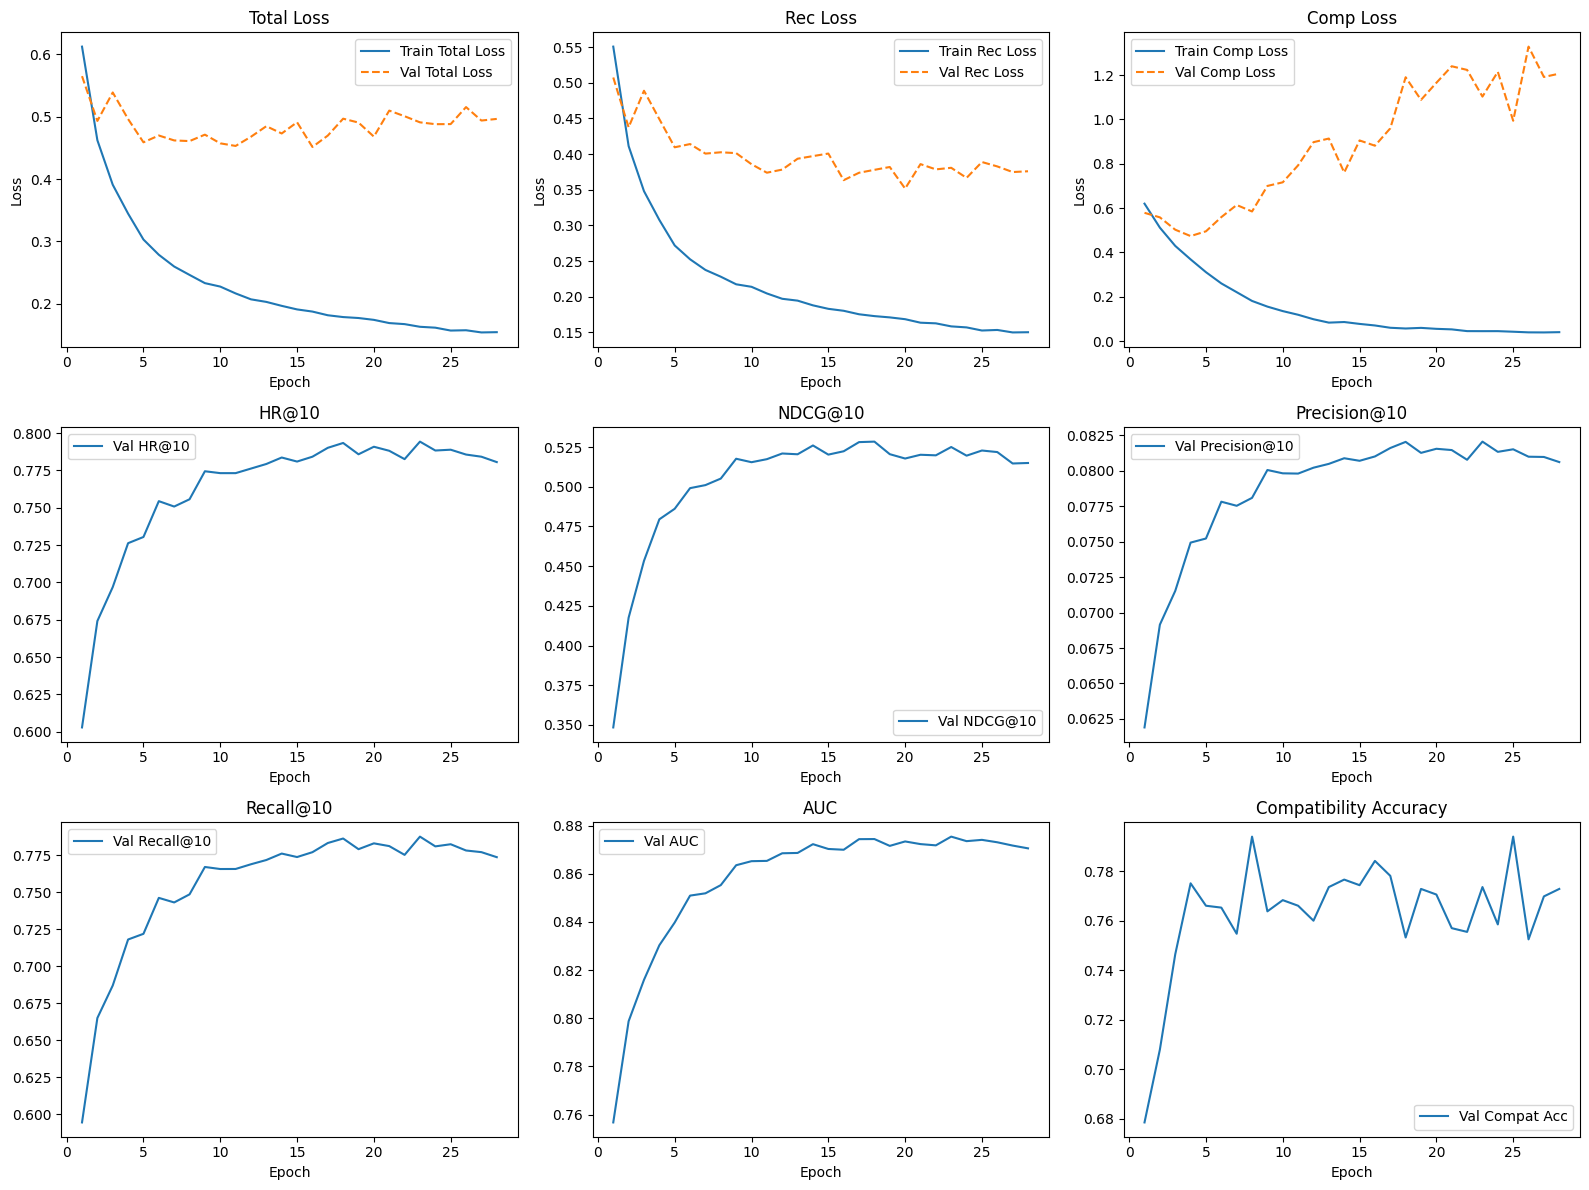

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

df = history_df.copy()

plt.figure(figsize=(16, 12))

# 1. Total Loss
plt.subplot(3,3,1)
plt.plot(df["epoch"], df["train_loss"], label="Train Total Loss")
plt.plot(df["epoch"], df["val_total_loss"], label="Val Total Loss", linestyle="--")
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# 2. Rec Loss
plt.subplot(3,3,2)
plt.plot(df["epoch"], df["train_rec_loss"], label="Train Rec Loss")
plt.plot(df["epoch"], df["val_rec_loss"], label="Val Rec Loss", linestyle="--")
plt.title("Rec Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# 3. Comp Loss
plt.subplot(3,3,3)
plt.plot(df["epoch"], df["train_comp_loss"], label="Train Comp Loss")
plt.plot(df["epoch"], df["val_comp_loss"], label="Val Comp Loss", linestyle="--")
plt.title("Comp Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# 4. HR@10
plt.subplot(3,3,4)
plt.plot(df["epoch"], df["HR@10"], label="Val HR@10")
plt.title("HR@10")
plt.xlabel("Epoch")
plt.legend()

# 5. NDCG@10
plt.subplot(3,3,5)
plt.plot(df["epoch"], df["NDCG@10"], label="Val NDCG@10")
plt.title("NDCG@10")
plt.xlabel("Epoch")
plt.legend()

# 6. Precision@10
plt.subplot(3,3,6)
plt.plot(df["epoch"], df["Precision@10"], label="Val Precision@10")
plt.title("Precision@10")
plt.xlabel("Epoch")
plt.legend()

# 7. Recall@10
plt.subplot(3,3,7)
plt.plot(df["epoch"], df["Recall@10"], label="Val Recall@10")
plt.title("Recall@10")
plt.xlabel("Epoch")
plt.legend()

# 8. AUC
plt.subplot(3,3,8)
plt.plot(df["epoch"], df["AUC"], label="Val AUC")
plt.title("AUC")
plt.xlabel("Epoch")
plt.legend()

# 9. Compatibility Accuracy
plt.subplot(3,3,9)
plt.plot(df["epoch"], df["compat_acc"], label="Val Compat Acc")
plt.title("Compatibility Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
# =========================
# 14) SAVE model.pt (best validation checkpoint)
# =========================
model_path = WORK_DIR / "model.pt"
history_path = WORK_DIR / "training_history.csv"
config_path = WORK_DIR / "run_config.json"
report_path = WORK_DIR / "validation_report.json"

history_df.to_csv(history_path, index=False)

save_json(
    {
        "DATA_ROOT": str(DATA_ROOT),
        "IMAGE_DIR": str(IMAGE_DIR),
        #"TARGET_NUM_USERS": TARGET_NUM_USERS,
        "IMAGE_BACKBONE": IMAGE_BACKBONE,
        "TEXT_MODEL_NAME": TEXT_MODEL_NAME,
        "EMBED_DIM": EMBED_DIM,
        "EPOCHS": EPOCHS,
        "LR": LR,
        "WEIGHT_DECAY": WEIGHT_DECAY,
        "LAMBDA_COMP": LAMBDA_COMP,
        "BATCH_SIZE": BATCH_SIZE,
        "VAL_RATIO": VAL_RATIO,
        "device_used": str(device),
    },
    config_path
)

validation_report = {
    "best_epoch": int(best_epoch),
    "best_metric": "NDCG@10",
    "best_metrics": best_metrics,
    "split_stats": split_stats,
}
save_json(validation_report, report_path)

if best_state_dict is None:
    best_state_dict = model.state_dict()

torch.save(
    {
        "model_state_dict": best_state_dict,
        "config": {
            "image_dim": int(image_feat_t.shape[1]),
            "text_dim": int(text_feat_t.shape[1]),
            "cat_dim": int(cat_feat_t.shape[1]),
            "num_users": int(len(user2idx)),
            "num_outfits": int(len(outfit2idx)),
            "num_items": int(len(item2idx)),
            "embed_dim": int(EMBED_DIM),
            "dropout": float(DROPOUT),
        },
        "mappings": {
            "user2idx": user2idx,
            "outfit2idx": outfit2idx,
            "item2idx": item2idx,
            "cat2idx": cat2idx,
        },
        "subsample_stats": {
            "sampled_users": int(train_uo_sub["user_id"].nunique()),
            "sampled_outfits": int(len(outfit_sub)),
            "sampled_items": int(len(item_sub)),
            "items_with_images": int(item_sub["has_image"].sum()),
        },
        "split_stats": split_stats,
        "validation_report": validation_report,
        "graph_data": {
            "A_item_indices": A_item.cpu().indices(),
            "A_item_values": A_item.cpu().values(),
            "A_item_size": A_item.shape,
            "A_outfit_item_indices": A_outfit_item.cpu().indices(),
            "A_outfit_item_values": A_outfit_item.cpu().values(),
            "A_outfit_item_size": A_outfit_item.shape,
            "A_user_outfit_indices": A_user_outfit_train.cpu().indices(),
            "A_user_outfit_values": A_user_outfit_train.cpu().values(),
            "A_user_outfit_size": A_user_outfit_train.shape,
            "A_user_outfit_full_indices": A_user_outfit_full.cpu().indices(),
            "A_user_outfit_full_values": A_user_outfit_full.cpu().values(),
            "A_user_outfit_full_size": A_user_outfit_full.shape,
        },
        "artifacts": {
            "feature_cache_path": str(feature_cache_path),
            "subsample_dir": str(SUB_DIR),
            "history_path": str(history_path),
            "config_path": str(config_path),
            "validation_report_path": str(report_path),
        },
        "history": history,
    },
    model_path
)

print("saved:", model_path.resolve())
print("saved:", history_path.resolve())
print("saved:", config_path.resolve())
print("saved:", report_path.resolve())


saved: /Users/quoctran/Documents/999999_HCMUS_Master_Exercises/HocPhan2/2_Research_Methods/hcmus-master-is-research-methods/hfgat_rewrite_validate/output_hfgat_notebook/model.pt
saved: /Users/quoctran/Documents/999999_HCMUS_Master_Exercises/HocPhan2/2_Research_Methods/hcmus-master-is-research-methods/hfgat_rewrite_validate/output_hfgat_notebook/training_history.csv
saved: /Users/quoctran/Documents/999999_HCMUS_Master_Exercises/HocPhan2/2_Research_Methods/hcmus-master-is-research-methods/hfgat_rewrite_validate/output_hfgat_notebook/run_config.json
saved: /Users/quoctran/Documents/999999_HCMUS_Master_Exercises/HocPhan2/2_Research_Methods/hcmus-master-is-research-methods/hfgat_rewrite_validate/output_hfgat_notebook/validation_report.json


In [29]:
# =========================
# 15) QUICK LOAD TEST
# =========================
ckpt = torch.load(WORK_DIR / "model.pt", map_location="cpu")
print("checkpoint keys:", list(ckpt.keys()))
print("num_users:", ckpt["config"]["num_users"])
print("num_outfits:", ckpt["config"]["num_outfits"])
print("num_items:", ckpt["config"]["num_items"])

checkpoint keys: ['model_state_dict', 'config', 'mappings', 'subsample_stats', 'split_stats', 'validation_report', 'graph_data', 'artifacts', 'history']
num_users: 25263
num_outfits: 6622
num_items: 14419


In [32]:
# =========================
# EXPORT USER / OUTFIT / ITEM EMBEDDINGS
# for output_hfgat_notebook style checkpoint
# =========================
from pathlib import Path
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
ARTIFACT_DIR = WORK_DIR
EXPORT_DIR = ARTIFACT_DIR / "exported_embeddings"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
class MLPBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.LayerNorm(out_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim),
        )
    def forward(self, x):
        return self.net(x)
class HFGATDetailed(nn.Module):
    def __init__(self, image_dim, text_dim, cat_dim, num_users, num_outfits, num_items, embed_dim=128, dropout=0.1):
        super().__init__()
        self.image_proj = nn.Linear(image_dim, embed_dim)
        self.text_proj = nn.Linear(text_dim, embed_dim)
        self.cat_proj = nn.Linear(cat_dim, embed_dim)
        self.item_fuse = MLPBlock(embed_dim * 3, embed_dim, dropout)
        self.item_update = MLPBlock(embed_dim, embed_dim, dropout)
        self.outfit_update = MLPBlock(embed_dim, embed_dim, dropout)
        self.user_update = MLPBlock(embed_dim, embed_dim, dropout)
        self.user_base = nn.Embedding(num_users, embed_dim)
        self.outfit_base = nn.Embedding(num_outfits, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.num_views = 6
        self.compat_mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, self.num_views)
        )
        # self.compat_mlp = nn.Sequential(
        #     nn.Linear(embed_dim, embed_dim),
        #     nn.ReLU(),
        #     nn.Linear(embed_dim, 1),
        # )
    def encode_items(self, image_x, text_x, cat_x, A_item_item):
        xi = F.normalize(self.image_proj(image_x), p=2, dim=-1)
        xt = F.normalize(self.text_proj(text_x), p=2, dim=-1)
        xc = F.normalize(self.cat_proj(cat_x), p=2, dim=-1)
        x = torch.cat([xi, xt, xc], dim=-1)
        x = self.item_fuse(x)
        x = F.normalize(x, p=2, dim=-1)
        x_prop = torch.sparse.mm(A_item_item, x)
        x = x + self.dropout(self.item_update(x_prop))
        return F.normalize(x, p=2, dim=-1)
    def encode_outfits(self, item_emb, A_outfit_item):
        agg = torch.sparse.mm(A_outfit_item, item_emb)
        base = F.normalize(self.outfit_base.weight, p=2, dim=-1)
        out = base + self.dropout(self.outfit_update(agg))
        return F.normalize(out, p=2, dim=-1)
    def encode_users(self, outfit_emb, A_user_outfit):
        agg = torch.sparse.mm(A_user_outfit, outfit_emb)
        base = F.normalize(self.user_base.weight, p=2, dim=-1)
        usr = base + self.dropout(self.user_update(agg))
        return F.normalize(usr, p=2, dim=-1)
    def forward(self, image_x, text_x, cat_x, A_item_item, A_outfit_item, A_user_outfit):
        item_emb = self.encode_items(image_x, text_x, cat_x, A_item_item)
        outfit_emb = self.encode_outfits(item_emb, A_outfit_item)
        user_emb = self.encode_users(outfit_emb, A_user_outfit)
        return user_emb, outfit_emb, item_emb
model_path = ARTIFACT_DIR / "model.pt"
ckpt = torch.load(model_path, map_location="cpu", weights_only=False)
g = ckpt.get("graph_data", {})
cfg = ckpt["config"]
mappings = ckpt["mappings"]
# The checkpoint was saved from the lighter HFGATLite architecture,
# not HFGATDetailed. Use HFGATLite to match the saved state dict.
model = HFGATLite(
    image_dim=cfg["image_dim"],
    text_dim=cfg["text_dim"],
    cat_dim=cfg["cat_dim"],
    num_users=cfg["num_users"],
    num_outfits=cfg["num_outfits"],
    num_items=cfg["num_items"],
    embed_dim=cfg["embed_dim"],
    dropout=cfg["dropout"],
)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
feature_cache_path = Path(ckpt.get("artifacts", {}).get("feature_cache_path", ARTIFACT_DIR / "cache" / "item_features.pt"))
cached = torch.load(feature_cache_path, map_location="cpu", weights_only=False)
item_features_df = cached["meta"].copy()
image_x = cached["image_feat"].float()
text_x = cached["text_feat"].float()
cat_x = cached["cat_feat"].float()
item2idx = mappings["item2idx"]
if image_x.shape[0] != len(item2idx):
    ordered_item_ids = [None] * len(item2idx)
    for item_id, idx in item2idx.items():
        ordered_item_ids[idx] = str(item_id)
    meta_idx = {str(x): i for i, x in enumerate(item_features_df["item_id"].astype(str).tolist())}
    reorder = [meta_idx[item_id] for item_id in ordered_item_ids]
    image_x = image_x[reorder]
    text_x = text_x[reorder]
    cat_x = cat_x[reorder]
    item_features_df = item_features_df.iloc[reorder].reset_index(drop=True)
print("Export feature shapes:", image_x.shape, text_x.shape, cat_x.shape)
A_item_item = torch.sparse_coo_tensor(
    g["A_item_indices"],
    g["A_item_values"],
    tuple(g["A_item_size"])
).coalesce()
A_outfit_item = torch.sparse_coo_tensor(
    g["A_outfit_item_indices"],
    g["A_outfit_item_values"],
    tuple(g["A_outfit_item_size"])
).coalesce()
user_graph_key = "A_user_outfit_indices" if "A_user_outfit_indices" in g else "A_user_outfit_full_indices"
user_graph_values_key = "A_user_outfit_values" if "A_user_outfit_values" in g else "A_user_outfit_full_values"
user_graph_size_key = "A_user_outfit_size" if "A_user_outfit_size" in g else "A_user_outfit_full_size"
A_user_outfit = torch.sparse_coo_tensor(
    g[user_graph_key],
    g[user_graph_values_key],
    tuple(g[user_graph_size_key])
).coalesce()
print("Export graph sizes:", A_item_item.shape, A_outfit_item.shape, A_user_outfit.shape)
with torch.no_grad():
    user_emb, outfit_emb, item_emb = model(
        image_x, text_x, cat_x,
        A_item_item, A_outfit_item, A_user_outfit
    )
user_emb = F.normalize(user_emb.cpu(), p=2, dim=-1)
outfit_emb = F.normalize(outfit_emb.cpu(), p=2, dim=-1)
item_emb = F.normalize(item_emb.cpu(), p=2, dim=-1)
torch.save(user_emb, EXPORT_DIR / "user_embeddings.pt")
torch.save(outfit_emb, EXPORT_DIR / "outfit_embeddings.pt")
torch.save(item_emb, EXPORT_DIR / "item_embeddings.pt")
for name in ["user2idx", "outfit2idx", "item2idx"]:
    with open(EXPORT_DIR / f"{name}.json", "w", encoding="utf-8") as f:
        json.dump(mappings[name], f, ensure_ascii=False, indent=2)
item_features_df.to_csv(EXPORT_DIR / "item_meta_ordered.csv", index=False)
outfit_items = {}
artifacts = ckpt.get("artifacts", {})
subsample_dir = artifacts.get("subsample_dir")
if subsample_dir:
    outfit_csv = Path(subsample_dir) / "outfit_sub.csv"
    if outfit_csv.exists():
        outfit_df = pd.read_csv(outfit_csv)
        for row in outfit_df.itertuples(index=False):
            raw = str(row.items) if not pd.isna(row.items) else ""
            outfit_items[str(row.outfit_id)] = [x.strip() for x in raw.split(";") if x.strip()] if raw else []
with open(EXPORT_DIR / "outfit_items.json", "w", encoding="utf-8") as f:
    json.dump(outfit_items, f, ensure_ascii=False, indent=2)
train_sub_csv = Path(artifacts.get("subsample_dir", ARTIFACT_DIR)) / "train_uo_sub.csv"
if train_sub_csv.exists():
    pd.read_csv(train_sub_csv).to_csv(EXPORT_DIR / "train_uo_sub.csv", index=False)
validation_report = ckpt.get("validation_report")
if validation_report is not None:
    with open(EXPORT_DIR / "validation_report.json", "w", encoding="utf-8") as f:
        json.dump(validation_report, f, ensure_ascii=False, indent=2)
print("Done.")
print("Saved to:", EXPORT_DIR.resolve())
for p in sorted(EXPORT_DIR.iterdir()):
    print("-", p.name)


Export feature shapes: torch.Size([14419, 2048]) torch.Size([14419, 768]) torch.Size([14419, 59])
Export graph sizes: torch.Size([14419, 14419]) torch.Size([6622, 14419]) torch.Size([25263, 6622])
Done.
Saved to: /Users/quoctran/Documents/999999_HCMUS_Master_Exercises/HocPhan2/2_Research_Methods/hcmus-master-is-research-methods/hfgat_rewrite_validate/output_hfgat_notebook/exported_embeddings
- item2idx.json
- item_embeddings.pt
- item_meta_ordered.csv
- outfit2idx.json
- outfit_embeddings.pt
- outfit_items.json
- train_uo_sub.csv
- user2idx.json
- user_embeddings.pt
- validation_report.json


## 16) Gợi ý chạy

- Mở notebook
- sửa cell config nếu cần
- bấm **Run All**
- file cuối cùng nằm ở:

```text
output_hfgat_notebook/model.pt
```

Nếu test nhanh trước:
- giảm `TARGET_NUM_USERS` xuống `5000`
- giảm `EPOCHS` xuống `2`

Khi chạy ổn rồi mới tăng lên.